# Librerías

In [2]:
# ============================================
# LIBRERÍAS BÁSICAS
# ============================================

import numpy as np              # Operaciones numéricas y manejo de arreglos
import pandas as pd             # Manipulación y análisis de datos en DataFrames


# ============================================
# VISUALIZACIÓN
# ============================================

import matplotlib.pyplot as plt # Creación de gráficos y visualizaciones


# ============================================
# PREPROCESAMIENTO Y MODELOS DE MACHINE LEARNING
# ============================================

from sklearn.preprocessing import MinMaxScaler  # Escalado de datos al rango [0,1]
from sklearn.neural_network import MLPRegressor # Red neuronal tipo perceptrón multicapa para regresión


# ============================================
# MÉTRICAS DE EVALUACIÓN
# ============================================

from sklearn.metrics import (
    mean_squared_error,  # Error cuadrático medio (MSE)
    mean_absolute_error, # Error absoluto medio (MAE)
    r2_score             # Coeficiente de determinación R²
)


# ============================================
# MODELOS DE SERIES DE TIEMPO
# ============================================

from statsmodels.tsa.statespace.sarimax import SARIMAX  # Modelo SARIMA/SARIMAX


# ============================================
# DIAGNÓSTICOS Y ANÁLISIS ESTADÍSTICO
# ============================================

from statsmodels.tsa.stattools import acf                # Cálculo de autocorrelación
from statsmodels.graphics.tsaplots import plot_acf       # Gráfico de autocorrelación
from statsmodels.graphics.gofplots import qqplot         # Gráfico QQ para normalidad
import statsmodels.api as sm                             # Funciones estadísticas generales
import scipy.stats as stats                              # Pruebas estadísticas


# ============================================
# UTILIDADES
# ============================================

import warnings  # Controlar advertencias del sistema
import time      # Medir tiempos de ejecución
import joblib    # Guardar y cargar modelos entrenados

warnings.filterwarnings("ignore")  # Oculta advertencias para mantener limpia la salida


# ============================================
# FUNCIONES: CARLOS SANTOS 
# ============================================

import sys
sys.path.append("Funciones")
import SeriesFuncionesGenerales_CarlosSantos as fg_cs
import importlib  
#importlib.reload(fg_cs) #PAra recargar el archivo de las funciones

In [3]:
# Cargar archivo CSV
# Leemos el archivo "nasdaq.csv" y lo guardamos en un DataFrame llamado df
df = pd.read_csv("nasdaq.csv")
df.head(5)

,Date
0,459.33
1,460.90
2,459.39
3,458.22
4,458.71


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1500 non-null   float64
dtypes: float64(1)
memory usage: 11.8 KB


In [5]:
# Mostramos las columnas que contiene el archivo
# Esto nos ayuda a verificar la estructura del dataset
print("Columnas encontradas:", df.columns)

Columnas encontradas: Index(['Date'], dtype='object')


In [6]:
# Renombrar columna
# Cambiamos el nombre de la(s) columna(s) a "value"
# Esto es útil cuando el archivo solo tiene una columna o queremos simplificar el nombre
df.columns = ["value"]
df.head(5)

,value
0,459.33
1,460.90
2,459.39
3,458.22
4,458.71


In [7]:
# Creamos un índice para visualizar la serie
# Generamos un índice numérico consecutivo desde 0 hasta el tamaño del DataFrame
# Esto nos permite tratar los datos como una serie de tiempo ordenada
df.index = pd.RangeIndex(start=0, stop=len(df), step=1)
df.head(5)

,value
0,459.33
1,460.90
2,459.39
3,458.22
4,458.71


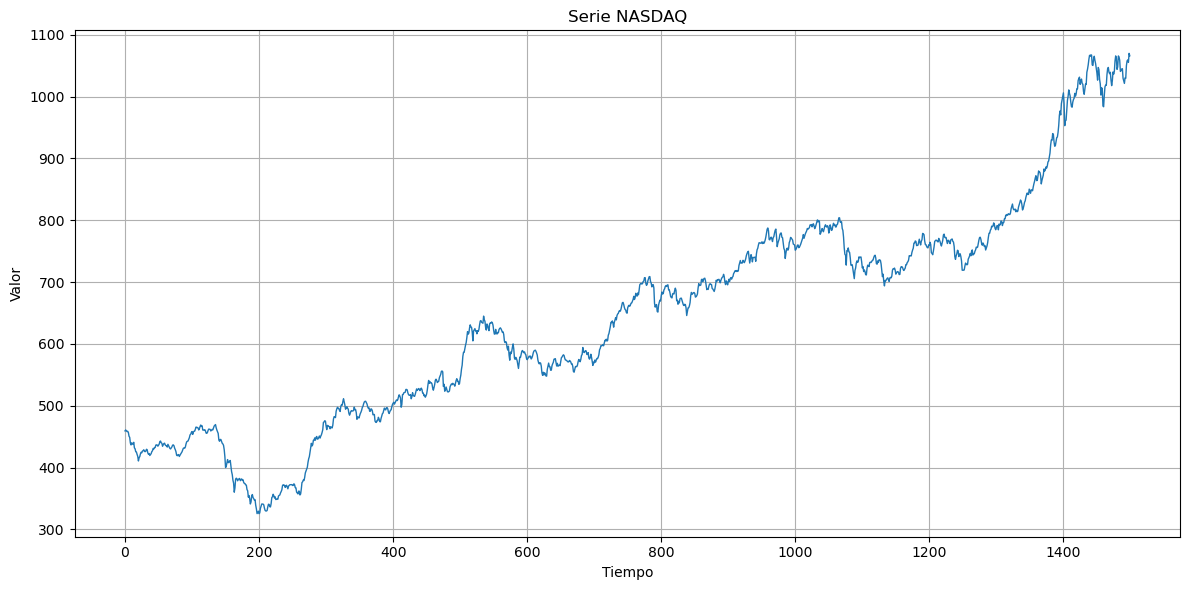


Serie visualizada correctamente.


In [8]:
# Visualizar la serie
# Definimos el tamaño de la figura
plt.figure(figsize=(12,6))

# Graficamos la columna "value"
# linewidth controla el grosor de la línea
plt.plot(df["value"], linewidth=1)

# Agregamos título y etiquetas a los ejes
plt.title("Serie NASDAQ")
plt.xlabel("Tiempo")
plt.ylabel("Valor")

# Activamos la cuadrícula para mejor lectura
plt.grid(True)

# Ajusta automáticamente los márgenes para que no se encimen los elementos
plt.tight_layout()

# Mostramos la gráfica
plt.show()

# Mensaje final para confirmar que el proceso terminó correctamente
print("\nSerie visualizada correctamente.")

# Valores perdidos

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   1500 non-null   float64
dtypes: float64(1)
memory usage: 11.8 KB


In [11]:
# Semilla para reproducibilidad
# Permite que los números aleatorios generados sean siempre los mismos
SEMILLA = 666

**Generar serie de prueba**

In [13]:
np.random.seed(SEMILLA) # Fijamos la semilla en numpy
n = 300 # Número de observaciones de la serie
t = np.arange(n) # Vector de tiempo (0,1,2,...,299)
t[-1] #último valor

299

In [14]:
t[:10] #Primeros 10 valores

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Generamos una serie artificial con:
- nivel base (10)
- tendencia lineal (0.03*t)
- componente estacional con seno
- ruido aleatorio con distribución normal

In [16]:
y = 10 + 0.03*t + 2*np.sin(2*np.pi*t/24) + np.random.normal(0, 0.6, size=n)
y[:10]

array([10.49451285, 10.83561769, 11.76408081, 12.0496424 , 11.50901794,
       12.01615329, 12.19141696, 11.57559501, 12.3563947 , 11.21234766])

Convertimos el arreglo a una Serie de pandas
- Usamos un índice numérico y nombramos la columna como <code> "value" </code>

In [18]:
s_full = pd.Series(y, index=pd.RangeIndex(n), name="value")
s_full.head(10)

0    10.494513
1    10.835618
2    11.764081
3    12.049642
4    11.509018
5    12.016153
6    12.191417
7    11.575595
8    12.356395
9    11.212348
Name: value, dtype: float64

Creamos una copia de la serie original para introducir valores faltantes

In [20]:
s_missing = s_full.copy()
s_missing.head(10)

0    10.494513
1    10.835618
2    11.764081
3    12.049642
4    11.509018
5    12.016153
6    12.191417
7    11.575595
8    12.356395
9    11.212348
Name: value, dtype: float64

Introducimos valores <code> NaN </code> en puntos aleatorios
- Seleccionamos $20$ posiciones aleatorias sin repetición

In [22]:
missing_idx = np.random.choice(n, size=20, replace=False)
missing_idx #Los índices que serán NaN

array([282, 219, 183, 177,  89,  37, 278, 163, 203,  75, 205, 267, 228,
        59, 139, 134,   1, 276, 168, 179])

Asignamos <code> NaN </code> en esas posiciones.

In [24]:
s_missing.loc[missing_idx] = np.nan
s_missing.loc[missing_idx]

282   NaN
219   NaN
183   NaN
177   NaN
89    NaN
37    NaN
278   NaN
163   NaN
203   NaN
75    NaN
205   NaN
267   NaN
228   NaN
59    NaN
139   NaN
134   NaN
1     NaN
276   NaN
168   NaN
179   NaN
Name: value, dtype: float64

**Introducción artificial de valores faltantes**

In [26]:
# Introducimos un bloque de valores faltantes consecutivos
# Esto simula una falla de medición o datos perdidos en un periodo
block_start, block_end = 120, 145 # [120, 145] los índices donde se podrán valores valtantes
s_missing.loc[block_start:block_end] = np.nan

A continuación, se obtienen los índices con valores <code> NaN </code>

In [28]:
missing_idx = s_missing[s_missing.isna()].index
missing_idx

Index([  1,  37,  59,  75,  89, 120, 121, 122, 123, 124, 125, 126, 127, 128,
       129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 163, 168, 177, 179, 183, 203, 205, 219, 228, 267, 276,
       278, 282],
      dtype='int64')

## Imputación con la media

**Sustitución**

In [31]:
mean_value = s_missing.mean(skipna=True) # Calculamos la media de la serie ignorando los valores NaN
mean_value

14.557154828270399

In [32]:
s_missing.head(10) #Obtenemos los 10 primeros valores

0    10.494513
1          NaN
2    11.764081
3    12.049642
4    11.509018
5    12.016153
6    12.191417
7    11.575595
8    12.356395
9    11.212348
Name: value, dtype: float64

In [33]:
s_mean = s_missing.fillna(mean_value) # Reemplazamos los NaN con la media calculada
s_mean.head(10)

0    10.494513
1    14.557155
2    11.764081
3    12.049642
4    11.509018
5    12.016153
6    12.191417
7    11.575595
8    12.356395
9    11.212348
Name: value, dtype: float64

## Eliminación (drop)

**Eliminación de segmentos:** Consiste en eliminar los valores perdidios, ya sean valores individuales o segmentos enteros de la serie.

**Cuando usarlo?**
- Cuando la eliminación no rompe la frecuencia temporal.
- Cuando la continuidad de la serie no es crítica.

**Limitaciones:**
- Puede afectar modelos como ARIMA/SARIMA que requieren continuidad.
- Reduce el tamaño de la muestra a la hora de entrenar el modelo

In [36]:
# Eliminamos completamente las observaciones que contienen NaN
s_drop = s_missing.dropna() # Esto reduce el tamaño de la serie
s_drop.head(10)

0     10.494513
2     11.764081
3     12.049642
4     11.509018
5     12.016153
6     12.191417
7     11.575595
8     12.356395
9     11.212348
10    11.665322
Name: value, dtype: float64

## Gráficas

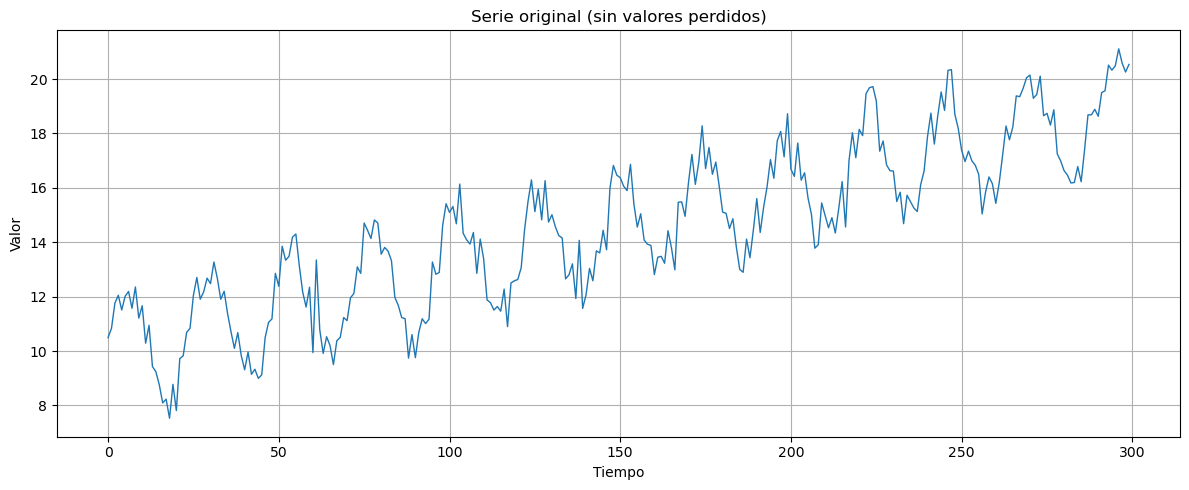

In [38]:
plt.figure(figsize=(12, 5)) # Se crea una figura con tamaño de 12x5 pulgadas
plt.plot(s_full, linewidth=1) # Se grafica la serie completa sin valores faltantes
plt.title("Serie original (sin valores perdidos)") # Título que describe el contenido de la gráfica
plt.xlabel("Tiempo") # Etiquetas de los ejes
plt.ylabel("Valor")
plt.grid(True) # Se agrega una cuadrícula para facilitar la lectura de la gráfica
plt.tight_layout() # Ajusta automáticamente los márgenes para evitar recortes en etiquetas
plt.show() # Muestra la gráfica en pantalla

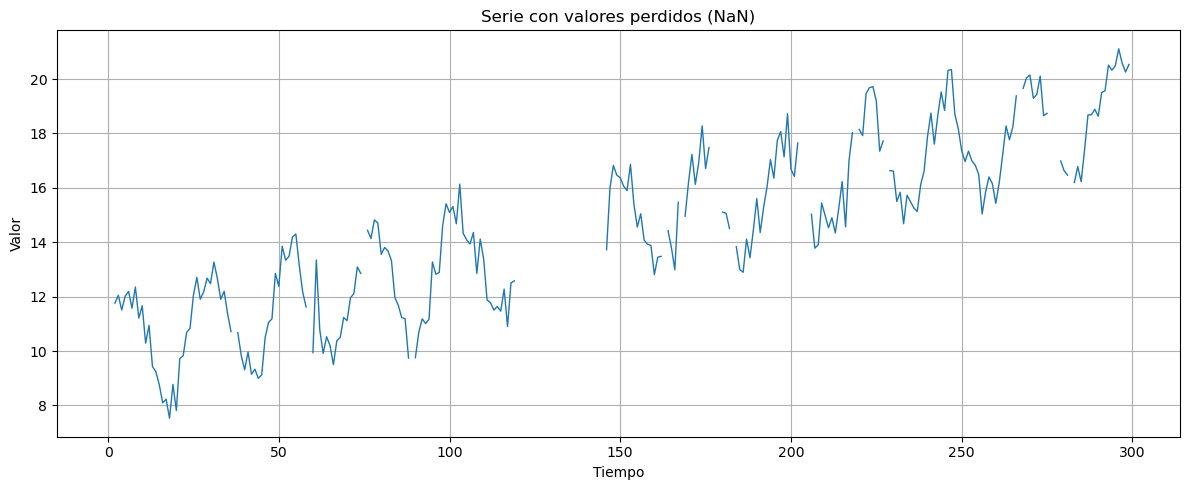

In [39]:
plt.figure(figsize=(12, 5)) # Se crea una nueva figura
# Se grafica la serie que contiene valores NaN
plt.plot(s_missing, linewidth=1) # En la gráfica aparecerán huecos donde existen datos faltantes
plt.title("Serie con valores perdidos (NaN)") # Título que indica que la serie contiene valores perdidos
plt.xlabel("Tiempo") # Etiquetas de los ejes
plt.ylabel("Valor")
plt.grid(True) # Cuadrícula para mejorar la visualización
plt.tight_layout() # Ajuste automático de los márgenes
plt.show() # Mostrar la gráfica

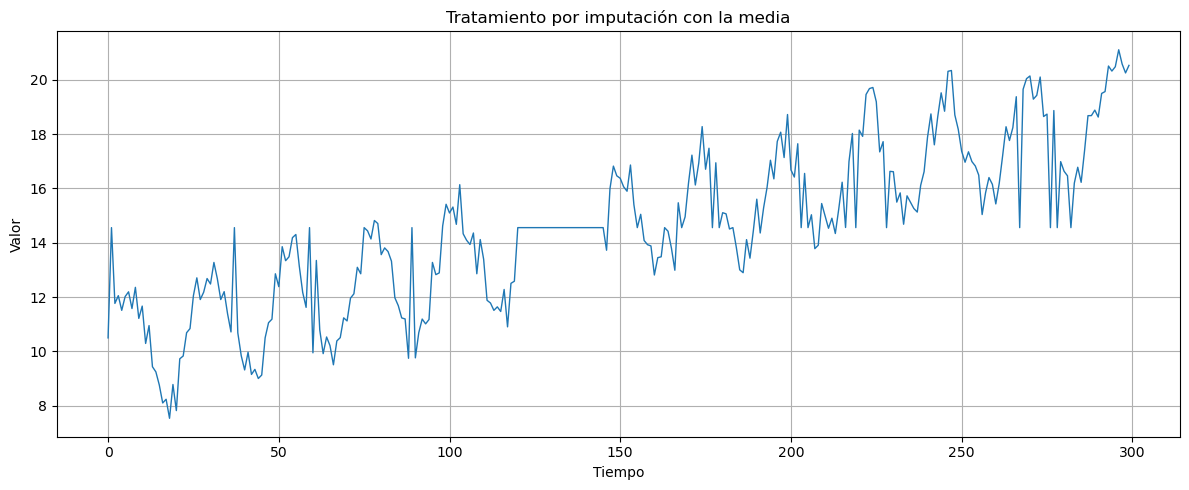

In [40]:
plt.figure(figsize=(12, 5)) # Se genera una nueva figura
plt.plot(s_mean, linewidth=1) # Se grafica la serie después de reemplazar los NaN por la media
plt.title("Tratamiento por imputación con la media")# Título que indica el método de tratamiento aplicado
plt.xlabel("Tiempo") # Etiquetas de los ejes
plt.ylabel("Valor") # Etiquetas de los ejes
plt.grid(True) # Cuadrícula
plt.tight_layout() # Ajuste de márgenes
plt.show() # Mostrar gráfica

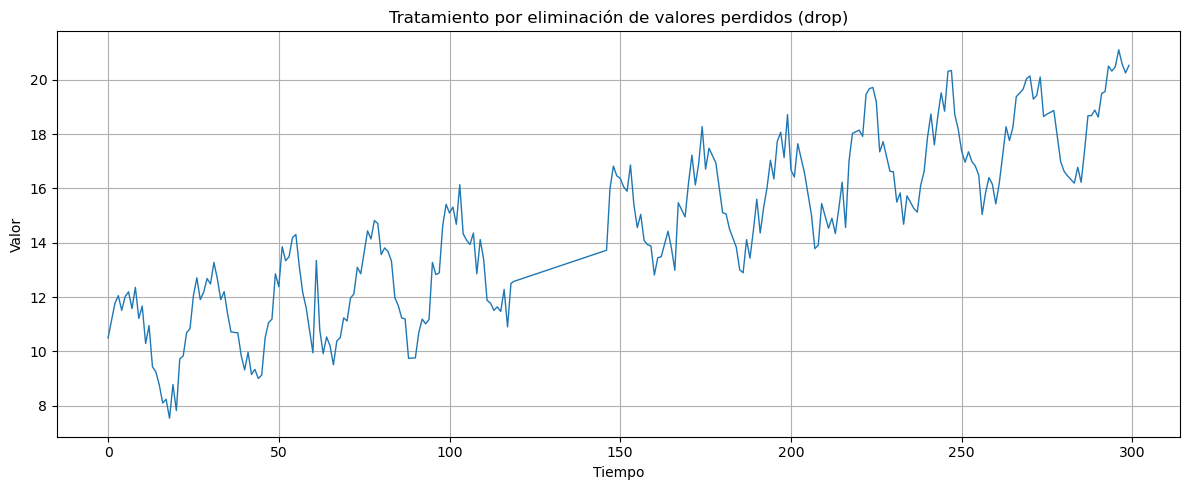

In [41]:
plt.figure(figsize=(12, 5)) # Se crea una nueva figura
# Se grafican explícitamente los índices y los valores
plt.plot(s_drop.index, s_drop.values, linewidth=1) # porque al eliminar los NaN la serie ya no es continua
plt.title("Tratamiento por eliminación de valores perdidos (drop)") # Título que describe el método aplicado
plt.xlabel("Tiempo") # Etiquetas de los ejes
plt.ylabel("Valor") # Etiquetas de los ejes
plt.grid(True) # Cuadrícula para mejorar la lectura
plt.tight_layout() # Ajuste automático del layout
plt.show() # Mostrar gráfica

**Resumen del proceso**

In [43]:
print("Resumen:") # Se imprime un resumen con información relevante sobre cómo cambiaron los datos durante el proceso
print(f"- Longitud original: {len(s_full)}") # Longitud de la serie original (número total de observaciones)
print(f"- NaN totales: {s_missing.isna().sum()}") # Cantidad total de valores faltantes (NaN) introducidos
print(f"- Media usada para imputación: {mean_value:.4f}") # Media calculada de la serie y utilizada para imputar los NaN
print(f"- Longitud tras eliminación: {len(s_drop)}") # Longitud final de la serie después de eliminar los NaN

Resumen:
- Longitud original: 300
- NaN totales: 44
- Media usada para imputación: 14.5572
- Longitud tras eliminación: 256


# Transformadas

Las **transformaciones** en series de tiempo son técnicas matemáticas aplicadas a los datos originales para:
- Estabilizar su varianza.
- Hacer la serie más estacionaria (que su media y varianza no cambien con el tiempo).
- Eliminar tenderncias y ciclos
  
Facilitando así su análisis y pronóstico

Cargar serie **NASDAQ**

In [47]:
file_path = "nasdaq.csv"
df = pd.read_csv(file_path)
df.head(5)

,Date
0,459.33
1,460.90
2,459.39
3,458.22
4,458.71


In [48]:
print("Columnas encontradas:", list(df.columns))

Columnas encontradas: ['Date']


In [49]:
if len(df.columns) == 1 and df.columns[0].lower() == "date":
    print(f"Verifica si el DataFrame tiene solo una columna y si el nombre de esa columna es 'date'")
    # Extrae la primera (y única) columna del DataFrame
    # .iloc[:,0] selecciona todas las filas de la columna 0
    # .astype(float) convierte los valores al tipo numérico flotante
    # .copy() crea una copia independiente para evitar modificar el DataFrame original
    s = df.iloc[:, 0].astype(float).copy()
    # Asigna un nombre a la serie resultante. Esto es útil para identificar la variable en análisis o gráficas
    s.name = "nasdaq"
     # Reemplaza el índice original por un índice entero secuencial
    # que comienza en 0 y termina en el número de observaciones - 1
    # Esto genera un índice tipo: 0,1,2,3,...,n
    s.index = pd.RangeIndex(start=0, stop=len(s), step=1)
s.head(10)

Verifica si el DataFrame tiene solo una columna y si el nombre de esa columna es 'date'


0    459.33
1    460.90
2    459.39
3    458.22
4    458.71
5    456.77
6    450.70
7    448.86
8    439.72
9    436.64
Name: nasdaq, dtype: float64

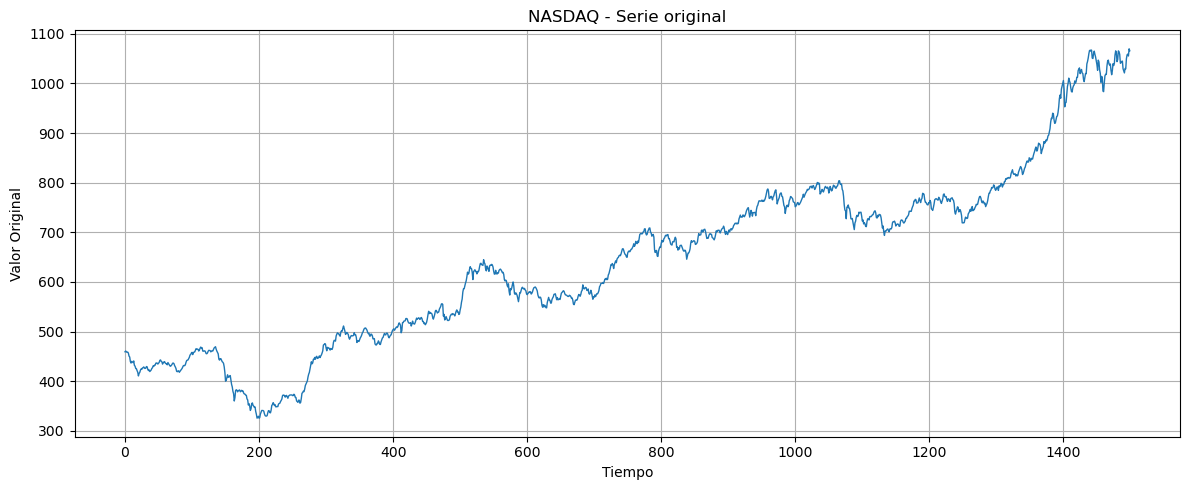

In [50]:
fg_cs.plot_series(s, "NASDAQ - Serie original", "Valor Original")

Limpieza de la serie elimnan valores problemáticos

In [52]:
# replace() busca valores específicos dentro de la serie
# En este caso busca:
# np.inf  -> infinito positivo (resultado de operaciones como dividir entre 0). Ejem: 10 / 0 
# -np.inf -> infinito negativo (por ejemplo log(0) o divisiones negativas entre 0). Ejem:  np.log(0)

# Como estos valores no son números finitos, pueden causar errores en análisis estadísticos o modelos de machine learning,
# por lo que primero se convierten a NaN y después se eliminan.

s = s.replace([np.inf, -np.inf], np.nan).dropna()
s

0        459.33
1        460.90
2        459.39
3        458.22
4        458.71
         ...   
1495    1057.60
1496    1059.20
1497    1055.30
1498    1069.80
1499    1065.90
Name: nasdaq, Length: 1500, dtype: float64

In [53]:
# replace() convierte los infinitos en valores faltantes (NaN)
# dropna() elimina todas las filas donde exista un NaN
# Al final obtenemos una serie limpia sin:
# - infinitos
# - valores faltantes

print(f"Longitud de serie: {len(s)}") # Imprime la cantidad total de observaciones que quedaron en la serie

# Calcula el valor mínimo de la serie :.4f formatea el número a 4 decimales
# Calcula también el valor máximo de la serie
print(f"Min={s.min():.4f}, Max={s.max():.4f}")

Longitud de serie: 1500
Min=325.4400, Max=1069.8000


## Transformación logarítmica

**¿Para que sirve?**

- Reduce la influencia de valores muy grandes (comprime la escala).
- Ayuda a estabilidar la varianza cuando la serie crece con el tiempo (heterocedasticidad).
- Convierte cambios multiplicativos en cambios aditivos (útil en finanzas)

In [56]:
# Calcula el valor mínimo de la serie. Esto se usa para verificar si existen valores cero o negativos
min_val = s.min()
min_val

325.44

In [57]:
# Inicializa la variable shift (desplazamiento) en 0. Este valor se utilizará solo si la serie contiene valores <= 0
shift = 0.0
shift

0.0

Verificamos si el valor mínimo de la serie es menor o igual a $0$.

Esto es importante porque el logaritmo natural no está definido para valores negativos ni para $0$.

In [59]:
if min_val <= 0:
    
    # Si existe un valor negativo o cero, se calcula un desplazamiento positivo
    # abs(min_val) convierte el valor mínimo en positivo
    # 1e-6 es un número muy pequeño agregado para evitar log(0)
    shift = abs(min_val) + 1e-6

Aplicamos la transformación logarítmica a la serie.
1. Se suma el desplazamiento (shift) a toda la serie para garantizar que todos los valores sean positivos.
2. Aplicar el lograitmo natural usando <code> np.log() </code>

In [61]:
s_log = np.log(s + shift)
s_log.head(10)

0    6.129769
1    6.133181
2    6.129900
3    6.127349
4    6.128418
5    6.124180
6    6.110802
7    6.106711
8    6.086138
9    6.079109
Name: nasdaq, dtype: float64

Asigna un nombre a la nueva serie transformada. Esto ayuda a identificar que ahora los datos están en escala logarítmica

In [63]:
s_log.name = "log(nasdaq)"
s_log.head(10)

0    6.129769
1    6.133181
2    6.129900
3    6.127349
4    6.128418
5    6.124180
6    6.110802
7    6.106711
8    6.086138
9    6.079109
Name: log(nasdaq), dtype: float64

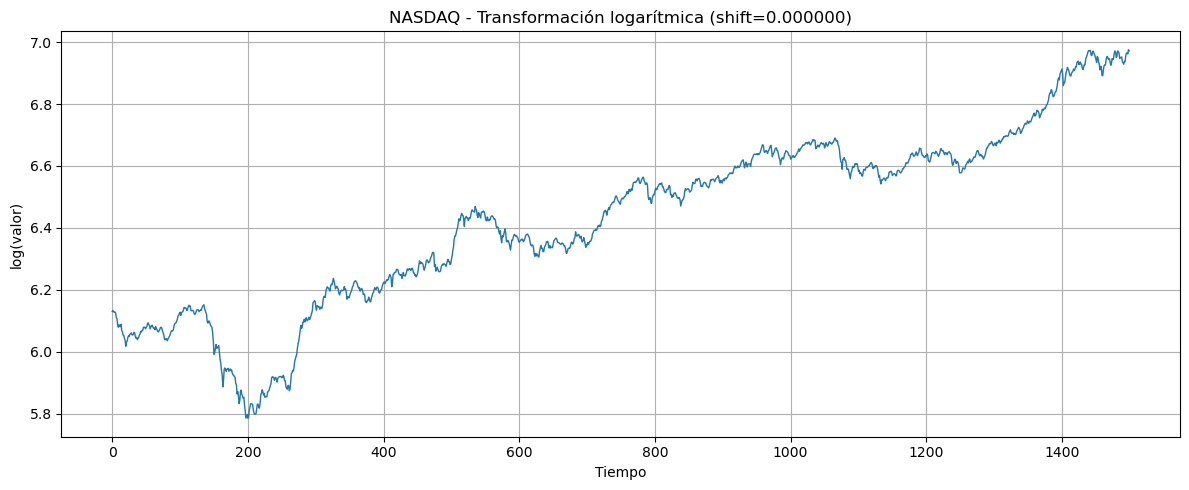

In [64]:
fg_cs.plot_series(s_log, f"NASDAQ - Transformación logarítmica (shift={shift:.6f})", "log(valor)" )

## Normalización (Min-Máx 0-1)

**¿Para que sirve?**
- Pone la serie en una escala comparable (ej. $0$ a $1$)
- Evita que los outliers dominen la serie

  $$ y'_t = \frac{y_t-min(y)}{max(y)-min(y)} $$

In [67]:
# Se crea un objeto del escalador MinMaxScaler
# Este método reescala los datos para que todos los valores
# queden dentro de un rango específico
# En este caso el rango será entre 0 y 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaler

MinMaxScaler()

In [68]:
# Se aplica la normalización a la serie
s_norm = pd.Series(
    
    # fit_transform() calcula el mínimo y máximo de los datos
    # y luego aplica la transformación de escalamiento
    # s.values obtiene los valores numéricos de la serie
    # reshape(-1,1) convierte el vector en una matriz columna
    # porque sklearn requiere datos en formato 2D
    # ravel() vuelve a convertir el resultado a un arreglo 1D
    scaler.fit_transform(s.values.reshape(-1, 1)).ravel(),
    
    # Se conserva el mismo índice de la serie original
    # para mantener la correspondencia temporal de los datos
    index=s.index,
    
    # Se asigna un nombre a la nueva serie normalizada
    name="nasdaq_norm_0_1"
)

In [69]:
s_norm.head()

0    0.179873
1    0.181982
2    0.179953
3    0.178381
4    0.179040
Name: nasdaq_norm_0_1, dtype: float64

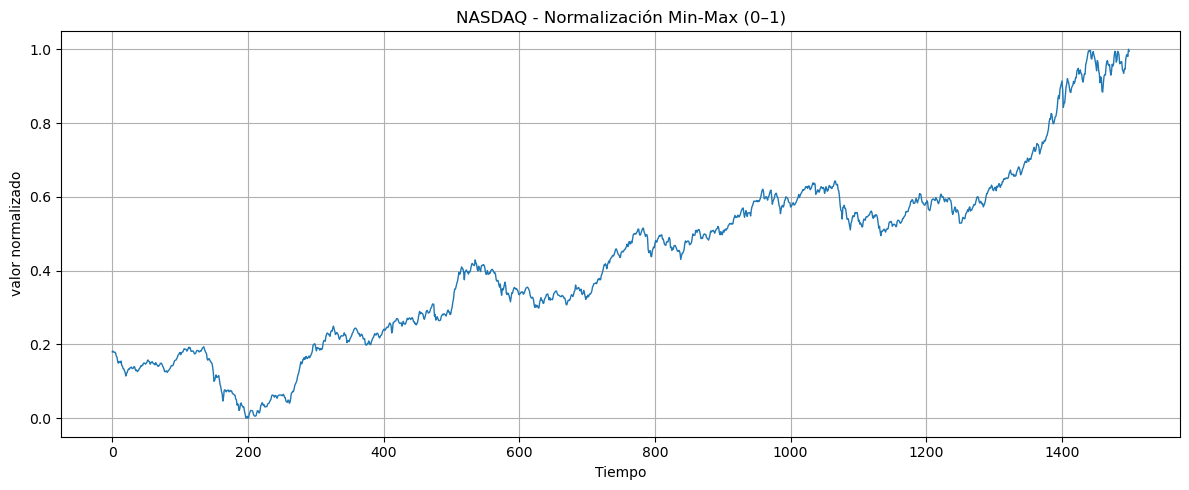

In [70]:
fg_cs.plot_series(s_norm, "NASDAQ - Normalización Min-Max (0–1)", "valor normalizado" )

## Diferenciación (1er orden)

Calcula la primera diferencia de la serieo riginal
**¿Para que sirve?**

Elimina tendencia y mejora la estacionariedad (clave para ARIMA/SARIMA)

<code>  diff(1) </code> resta cada valor con respecto al valor anterior:

$$diff_t = x_t-x_{t-1}$$

### Serie original

In [74]:
s.head()

0    459.33
1    460.90
2    459.39
3    458.22
4    458.71
Name: nasdaq, dtype: float64

In [75]:
460.90-459.33

1.5699999999999932

In [76]:
# Calcula la primera diferencia de la serie original
# diff(1) resta cada valor con respecto al valor anterior:
# diff_t = x_t - x_(t-1)
# Esto se usa mucho en series de tiempo para eliminar tendencias
s_diff = s.diff(1).dropna()

# dropna() elimina el primer valor de la serie,
# ya que no existe un dato previo para calcular la diferencia
# (por lo tanto el resultado inicial es NaN)

# Se asigna un nombre a la nueva serie transformada
s_diff.name = "diff(nasdaq)"
s_diff.head()

1    1.57
2   -1.51
3   -1.17
4    0.49
5   -1.94
Name: diff(nasdaq), dtype: float64

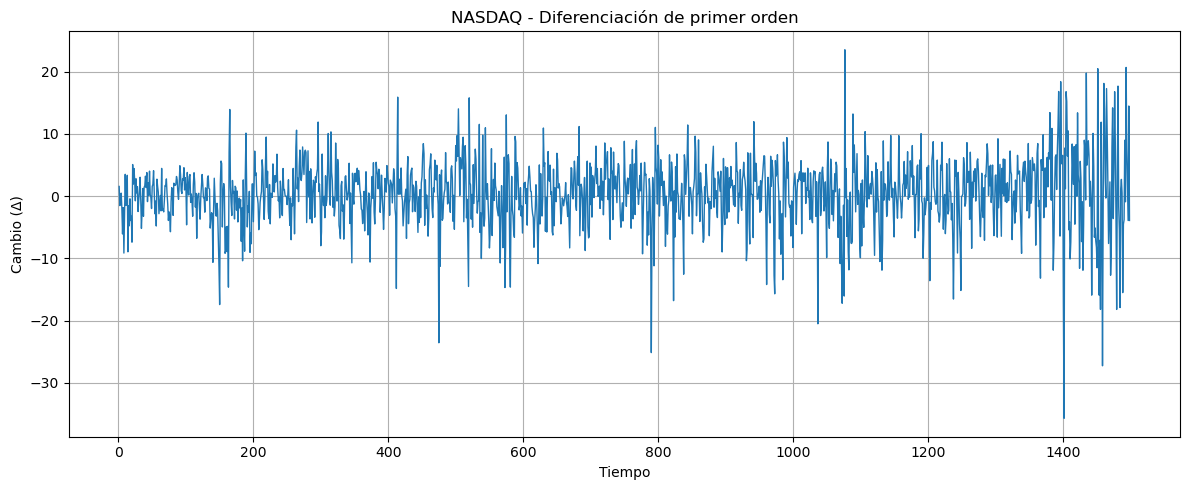

In [77]:
fg_cs.plot_series(s_diff, "NASDAQ - Diferenciación de primer orden", "Cambio (Δ)" ) 

### Serie transformada con logaritmo

In [79]:
# Calcula la primera diferencia de la serie transformada con logaritmo
# Primero la serie ya fue transformada con log:
# s_log = log(s)
# Luego se calcula la diferencia entre observaciones consecutivas
s_log_diff = s_log.diff(1).dropna() # Se elimina el primer NaN generado por la diferencia
# y se asigna un nombre a la serie resultante
s_log_diff.name = "diff(log(nasdaq))"
s_log_diff.head(5)

1    0.003412
2   -0.003282
3   -0.002550
4    0.001069
5   -0.004238
Name: diff(log(nasdaq)), dtype: float64

En este caso, la transformación equivale aproximadamente a calcular el crecimiento relativo o retorno logarítmico:

$$ log(x_t) - log(x_(t-1)) $$

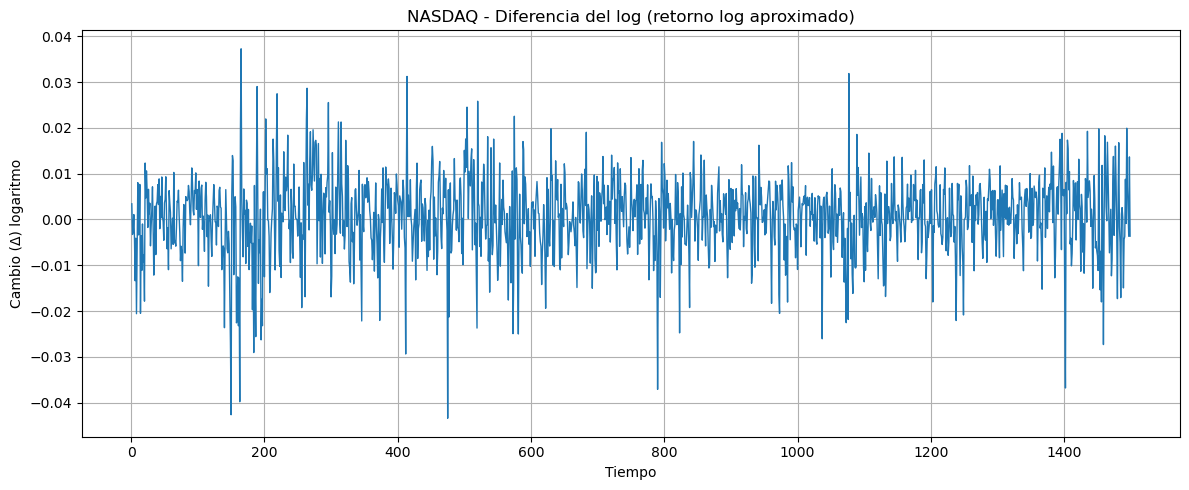

In [81]:
fg_cs.plot_series(s_log_diff, "NASDAQ - Diferencia del log (retorno log aproximado)", "Cambio (Δ) logaritmo" ) 

## Transformada de Fourier

**Recomendación:** Quitar la media para evitar que el DC domine.

**¿Para que sirve?**
- Detectar estacionalidades o ciclos (por ejemplo: cada $24$ muestras, cada $7$ días, etc.)

### Serie Original

FFT sobre serie original centrada

In [85]:
freqs, mag = fg_cs.fft_spectrum(s.values, dt=1.0)

Para evitar el pico en frecuencia $0$ (DC) al graficar, lo removemos visualmente.

In [87]:
mask_nonzero = freqs > 0

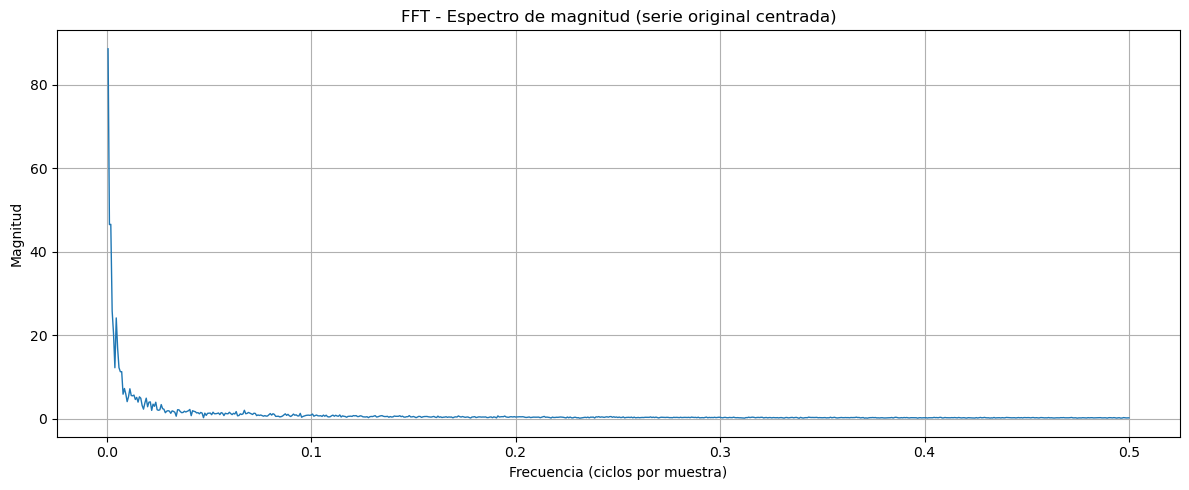

In [88]:
# Crea una figura para la gráfica con tamaño de 12x5 pulgadas Esto define el tamaño visual del gráfico
plt.figure(figsize=(12, 5))

# Grafica el espectro de frecuencias
# freqs contiene las frecuencias calculadas por la FFT
# mask_nonzero se usa para excluir la frecuencia 0 (componente DC)
# mag contiene la magnitud asociada a cada frecuencia
plt.plot(freqs[mask_nonzero], mag[mask_nonzero], linewidth=1)

# Título de la gráfica
# Indica que se está mostrando el espectro de magnitud de la serie original después de centrarla (restar la media)
plt.title("FFT - Espectro de magnitud (serie original centrada)")

# Etiqueta del eje X
# Representa las frecuencias presentes en la señal "ciclos por muestra" significa cuántos ciclos ocurren por unidad de muestreo
plt.xlabel("Frecuencia (ciclos por muestra)")

# Etiqueta del eje Y. Representa la magnitud o intensidad de cada frecuencia
plt.ylabel("Magnitud")

# Activa una cuadrícula para facilitar la lectura del gráfico
plt.grid(True)

# Ajusta automáticamente los márgenes de la figura
# para evitar que etiquetas o títulos se recorten
plt.tight_layout()

# Muestra la gráfica en pantalla
plt.show()

### Serie diferenciada

FFT sobre la serie diferenciada (suele mostrar mejor los ciclos)

In [91]:
freqs_d, mag_d = fg_cs.fft_spectrum(s_diff.values, dt=1.0)

Para evitar el pico en frecuencia 0 (DC) al graficar, lo removemos visualmente

In [93]:
mask_nonzero_d = freqs_d > 0

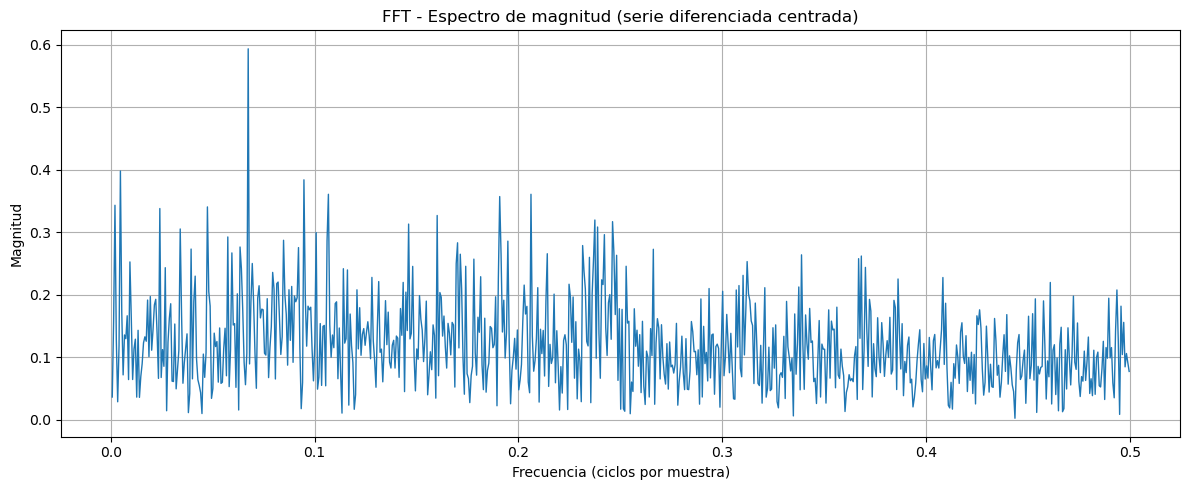

In [94]:
# Crear una nueva figura con tamaño de 12x5 pulgadas. Esto define el tamaño del gráfico que se mostrará
plt.figure(figsize=(12, 5))

# Graficar el espectro de frecuencias de la serie diferenciada
# freqs_d contiene las frecuencias obtenidas con la FFT
# mask_nonzero_d se usa para eliminar la frecuencia 0 (componente DC)
# mag_d contiene la magnitud o intensidad de cada frecuencia
plt.plot(freqs_d[mask_nonzero_d], mag_d[mask_nonzero_d], linewidth=1)

# Título del gráfico
# Indica que se está mostrando el espectro de magnitud de la serie diferenciada
# (es decir, después de aplicar la primera diferencia)
plt.title("FFT - Espectro de magnitud (serie diferenciada centrada)")

# Etiqueta del eje X
# Representa las frecuencias presentes en la serie "ciclos por muestra" significa cuántos ciclos ocurren por unidad de muestreo
plt.xlabel("Frecuencia (ciclos por muestra)")

# Etiqueta del eje Y: Representa la magnitud o intensidad de cada componente de frecuencia
plt.ylabel("Magnitud")

# Activa la cuadrícula para facilitar la lectura de la gráfica
plt.grid(True)

# Ajusta automáticamente los márgenes del gráfico para evitar que etiquetas o títulos se recorten
plt.tight_layout()

# Muestra la gráfica en pantalla
plt.show()

## Mostrar períodos dominantes

Mostramos los períodos dominantes aproximados (top $5$)
- Evitamos freqs = $0$

In [97]:
# Número de frecuencias dominantes que queremos identificar. En este caso se seleccionarán las 5 frecuencias más importantes
top_k = 5

# np.argsort ordena los índices según la magnitud del espectro
# mag[mask_nonzero] contiene las magnitudes de las frecuencias (sin la frecuencia 0)
# [::-1] invierte el orden para que quede de mayor a menor
# [:top_k] selecciona solo las k frecuencias más grandes
idx_sorted = np.argsort(mag[mask_nonzero])[::-1][:top_k]

top_freqs = freqs[mask_nonzero][idx_sorted] # Obtiene las frecuencias correspondientes a las mayores magnitudes

top_mags = mag[mask_nonzero][idx_sorted] # Obtiene las magnitudes asociadas a esas frecuencias dominantes

# Calcula el periodo asociado a cada frecuencia
# periodo = 1 / frecuencia
# Esto indica cada cuántas observaciones se repite el ciclo
top_periods = 1 / top_freqs

# Imprime un encabezado para los resultados
print("\nTop frecuencias dominantes (serie original centrada):")

# Recorre cada frecuencia dominante y muestra su información
for i, (f, m, p) in enumerate(zip(top_freqs, top_mags, top_periods), 1):
    
    # i -> número de ranking
    # f -> frecuencia
    # p -> periodo aproximado en número de muestras
    # m -> magnitud (importancia de esa frecuencia)
    print(f"{i}) f={f:.6f} -> periodo≈{p:.2f} muestras, magnitud={m:.6f}")


Top frecuencias dominantes (serie original centrada):
1) f=0.000667 -> periodo≈1500.00 muestras, magnitud=88.625522
2) f=0.002000 -> periodo≈500.00 muestras, magnitud=46.559830
3) f=0.001333 -> periodo≈750.00 muestras, magnitud=46.502870
4) f=0.002667 -> periodo≈375.00 muestras, magnitud=25.767200
5) f=0.004667 -> periodo≈214.29 muestras, magnitud=24.131334


Guardamos los resultados 

In [99]:
# Se crea un DataFrame con las principales transformaciones de la serie
# Cada columna representa una versión distinta de la serie original
out = pd.DataFrame({
    "original": s,     # Serie original
    "log": s_log,      # Serie transformada con logaritmo
    "norm_0_1": s_norm # Serie normalizada entre 0 y 1
})

# Se agrega una nueva columna con la primera diferencia de la serie original 
# diff(1) calcula x_t - x_(t-1), útil para eliminar tendencias
out["diff1"] = s.diff(1)

# Se agrega otra columna con la primera diferencia de la serie logarítmica
# Esto suele interpretarse como el crecimiento o retorno logarítmico
out["log_diff1"] = s_log.diff(1)

# Se guarda el DataFrame con todas las transformaciones en un archivo CSV
# index=True conserva el índice de la serie (por ejemplo tiempo o fecha)
out.to_csv("nasdaq_transformaciones_fft.csv", index=True)

In [100]:
out.head(5)

,original,log,norm_0_1,diff1,log_diff1
0,459.33,6.129769,0.179873,NaN,NaN
1,460.90,6.133181,0.181982,1.57,0.003412
2,459.39,6.129900,0.179953,-1.51,-0.003282
3,458.22,6.127349,0.178381,-1.17,-0.002550
4,458.71,6.128418,0.179040,0.49,0.001069


Se crea otro Dataframe para guardar el espectro de frecuencias de la **FFT**

In [102]:
# Se crea otro DataFrame para guardar el espectro de frecuencias de la FFT
fft_df = pd.DataFrame({
    "freq": freqs,  # Frecuencias obtenidas de la Transformada de Fourier
    "mag": mag      # Magnitud o intensidad de cada frecuencia
})

# Se guarda el espectro FFT en otro archivo CSV
# index=False porque el índice no es relevante en este caso
fft_df.to_csv("nasdaq_fft_spectrum.csv", index=False)

In [103]:
fft_df.head(5)

,freq,mag
0,0.000000,2.690588e-15
1,0.000667,8.862552e+01
2,0.001333,4.650287e+01
3,0.002000,4.655983e+01
4,0.002667,2.576720e+01


In [104]:
# Mensaje final para confirmar que los archivos fueron guardados correctamente
print("\nListo ✅ Se guardaron:")
print("- nasdaq_transformaciones_fft.csv")
print("- nasdaq_fft_spectrum.csv")


Listo ✅ Se guardaron:
- nasdaq_transformaciones_fft.csv
- nasdaq_fft_spectrum.csv


# Implementación de un Modelo SARIMA

ARIMA: AutoRegressive Integrated Moving Average

$$ARIMA(p,d,q)$$
Donde:
- $AR(p)$: Depende de valores pasados.
- $I(d)$: Número de diferenciadores de la serie.
- $MA(q)$: Dependencia a errores pasados.

SARIMA: Stationary AutoRegressive Integrated Moving Average

Extiende ARIMA para series estacionarias.
$$SARIMA(p,q,d)(P,D,Q)_S$$

donde:
- $AR(P)$: Depende de valores pasados estacionales.
- $I(D)$: Número de diferenciaciones a la serie estacional
- $MA(Q)$: Dependencia a errores pasados de la serie estacional.
- $S$: Estacionalidad de la serie (ej:semanas, meses, años).

## Configuración del modelo SARIMA(1,1,3)(2,1,1)[24]

<code> ORDER </code> define los parámetros del componente ARIMA no estacional 

In [109]:
# (p, d, q):
# p -> número de términos autoregresivos (AR)
# d -> número de diferenciaciones necesarias para volver la serie estacionaria
# q -> número de términos de media móvil (MA)
ORDER = (1, 1, 3)
ORDER

(1, 1, 3)

<code> SEASONAL_ORDER </code> define el componente estacional del modelo SARIMA

In [111]:
# (P, D, Q, s):
# P -> términos autoregresivos estacionales
# D -> número de diferenciaciones estacionales
# Q -> términos de media móvil estacionales
# s -> periodo de la estacionalidad (por ejemplo 24 observaciones)
SEASONAL_ORDER = (2, 1, 1, 24)
SEASONAL_ORDER

(2, 1, 1, 24)

<code> TREND </code> define el tipo de tendencia determinística incluida en el modelo:
- n: Sin tendencia ni constante.
- c: Incluye constante.
- t: Incluye tendencia lineal.
- ct: Incluye contsnate y tendencia

In [113]:
TREND = 'n'
TREND

'n'

## Cargamos datos

Se intenta cargar dos archivos:
- nasdaq_train.csv : datos de entrenamiento.
- nasdaq_test.csv  : datos de prueba.
  
Si los archivos no existen, el código genera datos sintéticos con comportamiento similar a una serie temporal real.

In [116]:
# Rutas de los archivos
train_path = 'nasdaq_train.csv'
test_path = 'nasdaq_test.csv'

# Lectura de los archivos CSV
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

Descripción de los valores del entrenamiento

In [118]:
train_df.head(5) #Los primeros 5 valoes

,value
0,459.33
1,460.90
2,459.39
3,458.22
4,458.71


In [119]:
train_df.shape

(1398, 1)

Descripción de los valores de prueba.

In [121]:
test_df.tail(5) #Los últimos 5 valores

,value
97,1057.6
98,1059.2
99,1055.3
100,1069.8
101,1065.9


Se extrae la columna 'value' que contiene la serie temporal

In [123]:
# Se extrae la columna 'value' que contiene la serie temporal
y_train = train_df['value'].values
y_test = test_df['value'].values

In [124]:
y_train[:5]

array([459.33, 460.9 , 459.39, 458.22, 458.71])

Creamos índices numéricos consecutivos para la serie

In [126]:
len(y_train) + 1 #Recordemos que python inicia en 0, por este motivo le agregamos 1

1399

In [127]:
len(y_train) + len(y_test) + 1  #Esto nos servirá para un indice continuo para la serie compelta

1501

In [128]:
# Se crean índices numéricos consecutivos para la serie
idx_train = pd.RangeIndex(1, len(y_train) + 1)
idx_test = pd.RangeIndex(len(y_train) + 1, len(y_train) + len(y_test) + 1)

In [129]:
idx_train

RangeIndex(start=1, stop=1399, step=1)

In [130]:
idx_test

RangeIndex(start=1399, stop=1501, step=1)

In [131]:
print(f"✓ Datos de entrenamiento cargados: {len(y_train)} puntos")
print(f"✓ Datos de prueba cargados: {len(y_test)} puntos")

✓ Datos de entrenamiento cargados: 1398 puntos
✓ Datos de prueba cargados: 102 puntos


**Conversión a series de pandas**

In [133]:
y_train_series = pd.Series(y_train, index=idx_train)
y_train_series.head()

1    459.33
2    460.90
3    459.39
4    458.22
5    458.71
dtype: float64

In [134]:
print(type(y_train_series))

<class 'pandas.core.series.Series'>


In [135]:
y_test_series = pd.Series(y_test, index=idx_test)
y_test_series.head()

1399     994.15
1400     999.33
1401    1005.90
1402     988.53
1403     952.83
dtype: float64

## Funciones de utilidad

Ejemplo:

In [138]:
y_real = np.array([100, 102, 101, 105, 107, 110, 108, 111, 115, 117])
y_pred = np.array([98, 103, 100, 106, 106, 111, 109, 110, 114, 118])

n = len(y_real)

print("y_real:", y_real)
print("y_pred:", y_pred)

y_real: [100 102 101 105 107 110 108 111 115 117]
y_pred: [ 98 103 100 106 106 111 109 110 114 118]


In [139]:
error = y_real - y_pred
print(error)

[ 2 -1  1 -1  1 -1 -1  1  1 -1]


Significado:
- Error positivo: El modelo **subestimo**
- Error negativo: El modelo **sobreestimo**

**Error Cuadrático Medio (MSE)**  

Mide el promedio del cuadrado de las diferencias entre los valores reales y los valores predichos por el modelo.

$$
MSE = \frac{1}{n}\sum_{t=1}^{n}(y_t - \hat{y}_t)^2
$$

Se utiliza para evaluar qué tan cerca están las predicciones del modelo respecto a los valores reales. Penaliza más los errores grandes debido al cuadrado.

In [142]:
mse = np.mean((y_real - y_pred)**2)
print("MSE =", mse)

MSE = 1.3


El 1er error pesa más (2) ya que $2^2=4$. Por esto esta métrica, **penaliza errores grandes**

In [144]:
print(mean_squared_error(y_real, y_pred)) #Scikit Learn

1.3


**Raíz del Error Cuadrático Medio (RMSE)**  

Es la raíz cuadrada del MSE, lo que permite interpretar el error en las mismas unidades que la variable original.

$$
RMSE = \sqrt{\frac{1}{n}\sum_{t=1}^{n}(y_t - \hat{y}_t)^2}
$$

Se usa para medir el tamaño promedio del error de predicción manteniendo las mismas unidades de los datos.


In [146]:
rmse = np.sqrt(mse)

print("RMSE =", rmse)
print(f"El error típico del modelo es aproximadamente, {rmse:.2f} unidades")

RMSE = 1.140175425099138
El error típico del modelo es aproximadamente, 1.14 unidades


**Error Absoluto Medio (MAE)**  

Mide el promedio de las diferencias absolutas entre los valores reales y los valores predichos.

$$
MAE = \frac{1}{n}\sum_{t=1}^{n}|y_t - \hat{y}_t|
$$

Sirve para evaluar el error promedio del modelo sin penalizar excesivamente los errores grandes.


In [148]:
mae = np.mean(np.abs(y_real - y_pred))

print("MAE =", mae)

print(f"Las predicciones se quivocan solo {mae:.2f} % respecto al valor real")

MAE = 1.1
Las predicciones se quivocan solo 1.10 % respecto al valor real


**SMAPE (Symmetric Mean Absolute Percentage Error)**  

Mide el error porcentual de forma simétrica entre los valores reales y predichos.

$$
SMAPE =
\frac{100}{n}
\sum_{t=1}^{n}
\frac{2|y_t - \hat{y}_t|}
{|y_t| + |\hat{y}_t|}
$$

Se utiliza para expresar el error en términos porcentuales, permitiendo comparar modelos incluso cuando las escalas de los datos son diferentes.


In [150]:
smape = 100 * np.mean(
    2 * np.abs(y_pred - y_real) /
    (np.abs(y_real) + np.abs(y_pred))
)

print("SMAPE =", smape, "%")

SMAPE = 1.0333711099158323 %


**Coeficiente de Determinación ($R^2$)**  

Indica qué proporción de la variabilidad de los datos es explicada por el modelo.

$$
R^2 =
1 -
\frac{\sum_{t=1}^{n}(y_t - \hat{y}_t)^2}
{\sum_{t=1}^{n}(y_t - \bar{y})^2}
$$

Se usa para medir la calidad del ajuste del modelo; valores cercanos a 1 indican un buen ajuste.


In [152]:
ss_res = np.sum((y_real - y_pred)**2)
ss_tot = np.sum((y_real - np.mean(y_real))**2)

r2 = 1 - (ss_res / ss_tot)

print("R² =", r2)
print(f"El modelo {r2*100:.2f}% explica de la variación de los datos")

R² = 0.9567243675099867
El modelo 95.67% explica de la variación de los datos


**Criterio de Información de Akaike (AIC)**  

Evalúa la calidad de un modelo considerando tanto el error como la complejidad del modelo.

$$
AIC = n \ln(MSE) + 2k
$$

donde  
- $n$ es el número de observaciones  
- $k$ es el número de parámetros del modelo  

Se utiliza para comparar modelos: el modelo con menor AIC suele considerarse mejor.


In [154]:
k = 3  # supongamos que el modelo tiene 3 parámetros
aic = n * np.log(mse) + 2 * k

print("AIC =", aic)

AIC = 8.623642644674911


**Criterio de Información Bayesiano (BIC)**  

Similar al AIC, pero penaliza más fuertemente los modelos con mayor número de parámetros.

$$
BIC = n \ln(MSE) + k \ln(n)
$$

Se utiliza para seleccionar modelos más simples cuando existen varias alternativas.


In [156]:
bic = n * np.log(mse) + k * np.log(n)

print("BIC =", bic)

BIC = 9.531397923657048


**MSE porcentual (%)**

Expresa el error cuadrático medio en términos porcentuales respecto al rango de los datos.

$$
MSE_{\%} =
\frac{100 \cdot MSE}
{(\max(y) - \min(y))^2}
$$

Permite interpretar el error en relación con la escala de los datos.


In [158]:
data_range = np.max(y_real) - np.min(y_real)

mse_percent = 100 * mse / (data_range**2)

print("MSE % =", mse_percent)
print(f"El MSE representa solo el {mse_percent:.2f} % del rango total de la serie.")

MSE % = 0.44982698961937717
El MSE representa solo el 0.45 % del rango total de la serie.


**RMSE relativo (%)**

Normaliza el RMSE respecto al rango de los datos.

$$
RMSE_{\%} =
\frac{100 \cdot RMSE}
{\max(y) - \min(y)}
$$

Se utiliza para interpretar el tamaño del error de predicción en términos porcentuales respecto a la variabilidad de los datos.

## Entrenar modelo SARIMA

In [161]:
print(f"Modelo: SARIMA{ORDER}{SEASONAL_ORDER[:-1]}[{SEASONAL_ORDER[-1]}] | trend='{TREND}'")

Modelo: SARIMA(1, 1, 3)(2, 1, 1)[24] | trend='n'


In [162]:
start_time_final = time.time() #Inicio del modelo

Se crea y entrena un modelo SARIMA utilizando la clase SARIMAX.

**SARIMA = Seasonal AutoRegressive Integrated Moving Average.**

Este modelo captura:
- Componentes autorregresivos (AR)
- Diferenciación para estacionariedad (I)
- Componentes de media móvil (MA)
- Componentes estacionales (S)

$ORDER = (p, d, q)$
- $p$ → número de términos autorregresivos (AR)
- $d$ → número de diferenciaciones para volver estacionaria la serie
- $q$ → número de términos de media móvil (MA)

$$y_t = c + φ₁y_{t-1} + φ₂y_{t-2} + ... + φ_p y_{t-p}  + ε_t + θ₁ε_{t-1} + θ₂ε_{t-2} + ... + θ_q ε_{t-q}$$

$SEASONAL_ORDER = (P, D, Q, s)$

- $P$: Términos AR estacionales
- $D$: Diferenciación estacional
- $Q$: Términos MA estacionales
- $s$: Longitud del ciclo estacional

- Ejemplo: $s=24$ indica una estacionalidad cada 24 observaciones

Matemáticamente incluye términos como:
    $$Φ₁ y_{t-s} + Φ₂ y_{t-2s}$$

Tipo de tendencia determinística del modelo
    
- 'n': Sin tendencia
- 'c': Constante
- 't': Tendencia lineal
- 'ct': Constante + tendencia

Ejemplo con constante:
 $$y_t = c + AR + MA + ε_t$$

In [165]:
modelo_final = SARIMAX(
    # Serie temporal de entrenamiento que el modelo intentará explicar y utilizar para aprender la dinámica de la serie.
    y_train_series,
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    trend=TREND,
    # Si fuera True, el modelo obliga a que el proceso AR cumpla la condición de estacionariedad: |φ| < 1
    # Se desactiva porque muchas series reales requieren  parámetros fuera de esa restricción durante la estimación.
    enforce_stationarity=False,
    # Si fuera True, obliga a que el proceso MA sea invertible:|θ| < 1
    # Desactivarlo permite que el optimizador explore más soluciones.
    enforce_invertibility=False
# Ajuste del modelo (estimación de parámetros) Se utilizan métodos de máxima verosimilitud.
# Se estiman parámetros como: φ (AR), θ (MA), Φ (estacionales), σ² (varianza del error)
).fit(
    disp=False, # disp=False evita mostrar la salida completa del optimizador
     # número máximo de iteraciones del algoritmo de optimización (normalmente L-BFGS o métodos similares)
    maxiter=100
)

In [166]:
training_time_final = time.time() - start_time_final

print(f"✓ Modelo entrenado en {training_time_final:.2f} segundos")

✓ Modelo entrenado en 588.16 segundos


In [167]:
training_time_final/60

9.802667737007141

## Predicciones y métricas

### Predicciones dentro de la muestra (IN-SAMPLE

<code>  fittedvalues  </code>  contiene las predicciones del modelo para los mismos datos con los que fue entrenado.
Es decir, el modelo intenta reconstruir la serie original utilizando los parámetros estimados.


Matemáticamente el modelo genera:

$$
\hat{y}_t = E\left(y_t \mid \text{información hasta } t-1\right)
$$

donde:

$$
\hat{y}_t = \text{valor predicho}
$$

$$
y_t = \text{valor real}
$$

In [170]:
y_train_pred = modelo_final.fittedvalues
y_train_pred[:5]

1      0.000000
2    606.506313
3    515.912545
4    479.073352
5    464.911669
dtype: float64

In [171]:
y_train[:5]

array([459.33, 460.9 , 459.39, 458.22, 458.71])

### Ajustar longitud de las series

A veces las predicciones tienen una longitud ligeramente diferente a la serie original debido a:

- diferenciación ($d$)
- diferenciación estacional ($D$)

 Por eso se toma la longitud mínima para que ambas series tengan el mismo tamaño antes de calcular métricas.

In [174]:
len(y_train_series)

1398

In [175]:
len(y_train_pred)

1398

In [176]:
min_len_train = min(len(y_train_series), len(y_train_pred))
min_len_train

1398

In [177]:
y_train_actual = y_train_series.values[:min_len_train] # Valores reales de entrenamiento
y_train_pred_vals = y_train_pred.values[:min_len_train] # Valores predichos por el modelo

In [178]:
y_train_actual[:10] #Los 10 primeros valores del entrenamiento

array([459.33, 460.9 , 459.39, 458.22, 458.71, 456.77, 450.7 , 448.86,
       439.72, 436.64])

In [179]:
y_train_pred_vals[:10]  #Los 10 primeros valores del modelo

array([  0.        , 606.5063132 , 515.91254519, 479.07335198,
       464.91166946, 461.50633777, 456.68114928, 447.10797815,
       446.43437024, 433.4518764 ])

### Predicción fuera de la muestra (OUT-OF-SAMPLE)

Aquí el modelo genera pronósticos hacia el futuro, es decir, valores que NO vio durante el entrenamiento.

<code> forecast_sarima </code> devuelve:
- media del pronóstico
- límite inferior del intervalo de confianza
- límite superior del intervalo de confianza



In [182]:
y_test_pred, y_test_low, y_test_up = fg_cs.forecast_sarima( 
    modelo_final, # modelo SARIMA entrenado
    y_train_series,  # serie usada para entrenamiento sirve como referencia para continuar el índice temporal
    len(y_test_series) # número de pasos a pronosticar normalmente coincide con el tamaño del conjunto de prueba
)

### Número de parámetros del modelo

<code> params </code> contiene todos los parámetros estimados:
- coeficientes $AR$
- coeficientes $MA$
- coeficientes estacionales
- varianza del error
  
Este número se usa para calcular métricas de penalización de complejidad como:


$$AIC = n log(MSE) + 2k$$

$$BIC = n log(MSE) + k log(n)$$



donde:
- k = número de parámetros

In [185]:
n_params = len(modelo_final.params)
n_params

8

### Cálculo de métricas

#### Entrenamiento

Se compararan valores reales vs predicciones del entrenamiento

- Permite evaluar qué tan bien el modelo explica los datos que utilizó para entrenarse.

In [189]:
metrics_in = fg_cs.calcular_metricas(
    y_train_actual,  # valores reales
    y_train_pred_vals, # valores predichos
    n_params, # número de parámetros
    "in" # etiqueta para identificar el conjunto
)

#### Prueba

Aquí se comparan los valores reales del conjunto de prueba contra los pronósticos generados por el modelo.
- Este es el resultado más importante porque mide la capacidad de generalización del modelo.

In [192]:
metrics_out = fg_cs.calcular_metricas(
    y_test_series.values,  # valores reales de prueba
    y_test_pred.values, # valores predichos por el modelo
    n_params, # número de parámetros del modelo
    "out" # número de parámetros del modelo
)

### Impresión de resultados

In [194]:
print("IN-SAMPLE (Entrenamiento):")
print(f"  MSE: {metrics_in['MSE_in']:.6f} ({metrics_in['MSE_in_%']:.2f}%)")
print(f"  RMSE: {metrics_in['RMSE_in']:.6f} ({metrics_in['RMSE_in_%']:.2f}%)")
print(f"  MAE: {metrics_in['MAE_in']:.6f}")
print(f"  SMAPE: {metrics_in['SMAPE_in_%']:.2f}%")
print(f"  R²: {metrics_in['R2_in']:.4f}")
print(f"  AIC: {metrics_in['AIC_in']:.2f}")
print(f"  BIC: {metrics_in['BIC_in']:.2f}")

IN-SAMPLE (Entrenamiento):
  MSE: 278.453516 (0.06%)
  RMSE: 16.686927 (2.52%)
  MAE: 4.582031
  SMAPE: 0.89%
  R²: 0.9872
  AIC: 7885.69
  BIC: 7927.64


In [195]:
print("\nOUT-OF-SAMPLE (Prueba):")
print(f"  MSE: {metrics_out['MSE_out']:.6f} ({metrics_out['MSE_out_%']:.2f}%)")
print(f"  RMSE: {metrics_out['RMSE_out']:.6f} ({metrics_out['RMSE_out_%']:.2f}%)")
print(f"  MAE: {metrics_out['MAE_out']:.6f}")
print(f"  SMAPE: {metrics_out['SMAPE_out_%']:.2f}%")
print(f"  R²: {metrics_out['R2_out']:.4f}")
print(f"  AIC: {metrics_out['AIC_out']:.2f}")
print(f"  BIC: {metrics_out['BIC_out']:.2f}")


OUT-OF-SAMPLE (Prueba):
  MSE: 483.295905 (3.53%)
  RMSE: 21.983992 (18.79%)
  MAE: 17.512052
  SMAPE: 1.70%
  R²: 0.3298
  AIC: 646.42
  BIC: 667.42


## Visualizaciones

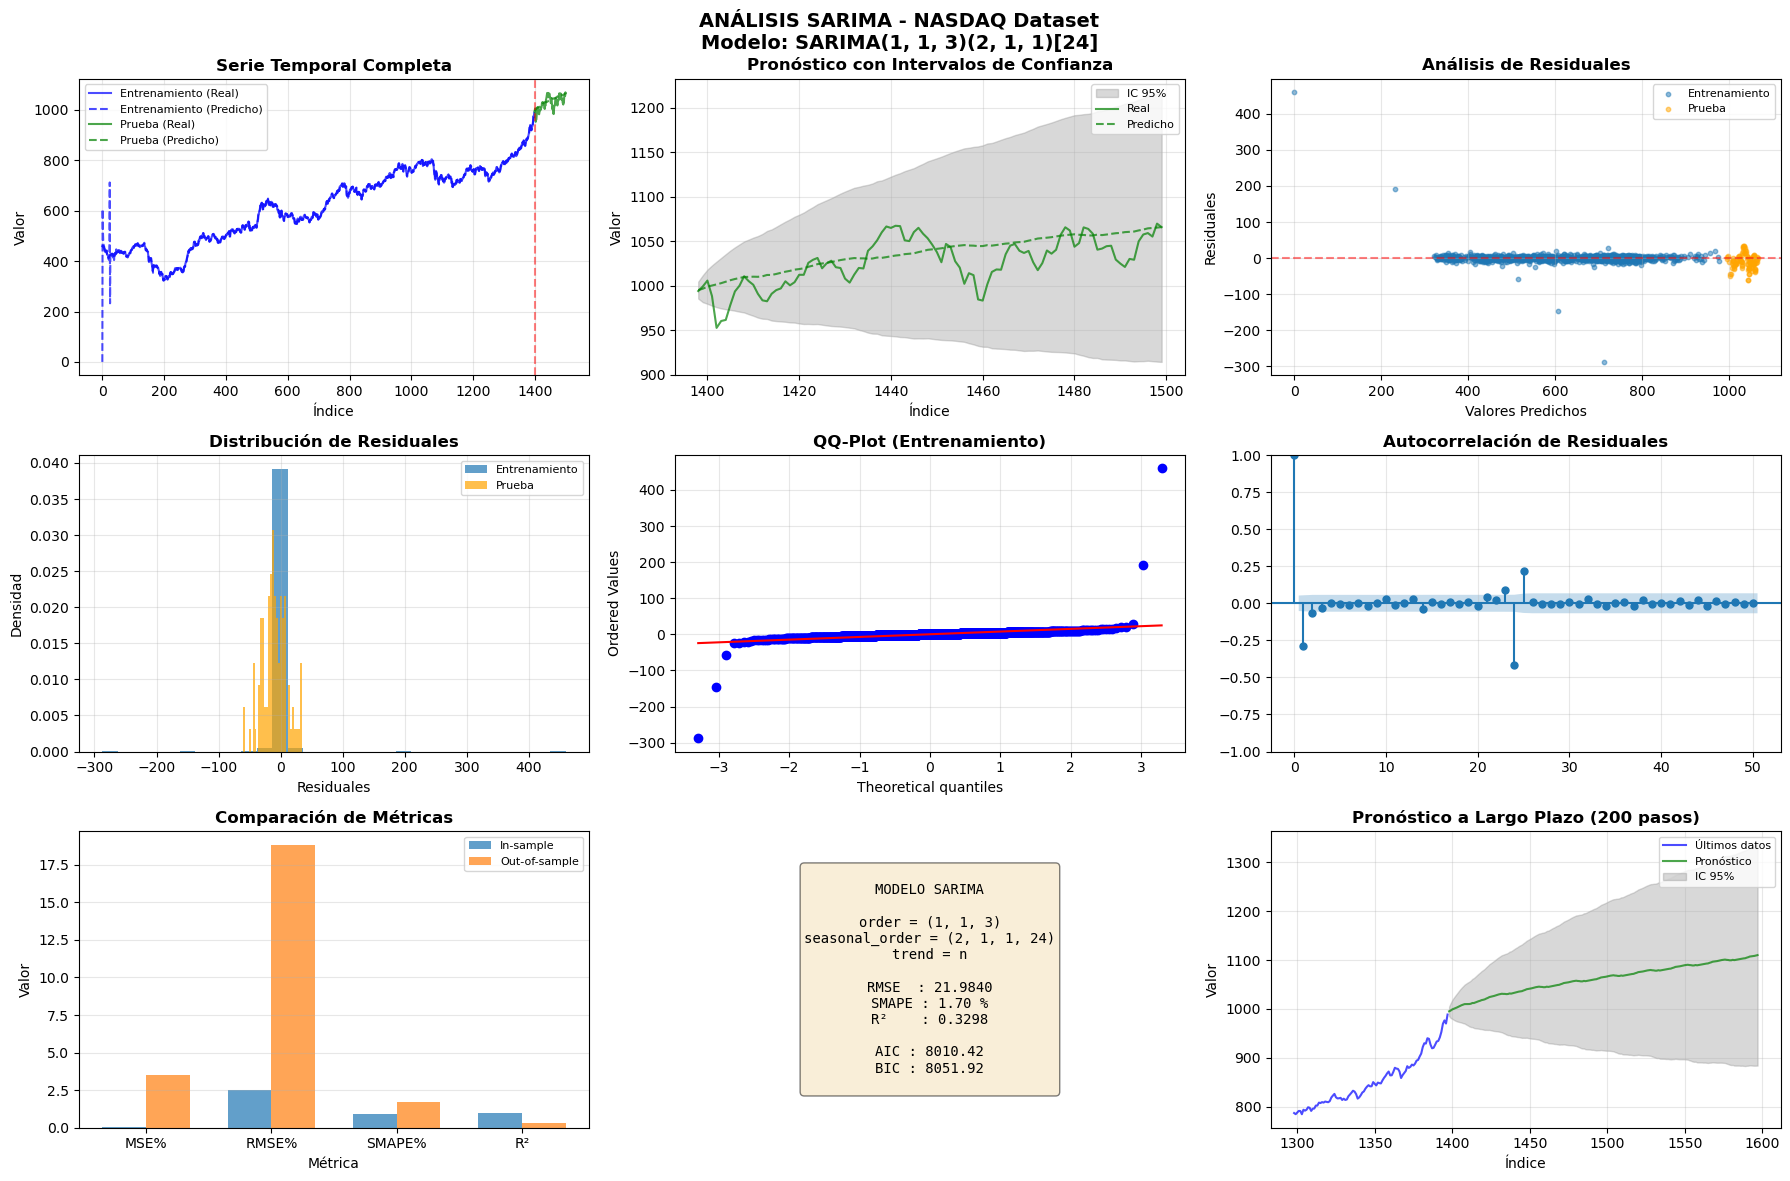

In [197]:
viz_Sarima = fg_cs.graficar_diagnostico_modelo_SARIMA(
    y_train_actual,
    y_train_pred_vals,
    y_test_series,
    y_test_pred,
    y_test_low,
    y_test_up,
    metrics_in,
    metrics_out,
    modelo_final,
    ORDER,
    SEASONAL_ORDER,
    TREND, y_train_series
)

In [198]:
viz_Sarima .savefig("diagnostico_modelo_sarima.png", dpi=300, bbox_inches="tight")

## Guardando Resultados

In [200]:
joblib.dump(modelo_final, 'sarima_fixed_model.pkl')
print("✓ Modelo guardado en 'sarima_fixed_model.pkl'")

with open('sarima_fixed_metrics.txt', 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("RESULTADOS SARIMA\n")
    f.write("=" * 60 + "\n\n")

    f.write("MODELO UTILIZADO:\n")
    f.write("-" * 40 + "\n")
    f.write(f"order={ORDER}\n")
    f.write(f"seasonal_order={SEASONAL_ORDER}\n")
    f.write(f"trend='{TREND}'\n")
    f.write(f"AIC (modelo): {modelo_final.aic:.6f}\n")
    f.write(f"BIC (modelo): {modelo_final.bic:.6f}\n\n")

    f.write("MÉTRICAS IN-SAMPLE (Entrenamiento):\n")
    f.write("-" * 40 + "\n")
    for key, value in metrics_in.items():
        if 'n_' not in key:
            f.write(f"{key}: {value:.6f}\n")
    f.write("\n")

    f.write("MÉTRICAS OUT-OF-SAMPLE (Prueba):\n")
    f.write("-" * 40 + "\n")
    for key, value in metrics_out.items():
        if 'n_' not in key:
            f.write(f"{key}: {value:.6f}\n")
    f.write("\n")

print("✓ Métricas guardadas en 'sarima_fixed_metrics.txt'")

print("\n" + "=" * 60)
print("¡PROCESO COMPLETADO EXITOSAMENTE!")
print("=" * 60)

✓ Modelo guardado en 'sarima_fixed_model.pkl'
✓ Métricas guardadas en 'sarima_fixed_metrics.txt'

¡PROCESO COMPLETADO EXITOSAMENTE!


# Implementación de la ARnet

Es una arquitectura de red neuronal diseñada para tareas de regresión (En Python se le conoce como **MLPRegressor**)

## Evaluación de Resultados del modelo ARNET

Para evaluar el desempeño del modelo **ARNET (Artificial Neural Network for Time Series)** se utilizan métricas estándar de pronóstico de series de tiempo. Estas métricas permiten comparar los valores reales de la serie con los valores estimados por la red neuronal.

Sean $\{y_t\}_{t=1}^{n}$ los valores reales de la serie y $\{\hat{y}_t\}_{t=1}^{n}$ los valores pronosticados por el modelo **ARNET** en el conjunto de prueba.

**Root Mean Square Error (RMSE)**

El **RMSE** mide la magnitud promedio del error cuadrático entre los valores reales y los predichos.

$$
RMSE = \sqrt{\frac{1}{n}\sum_{t=1}^{n}(y_t - \hat{y}_t)^2}
$$

**Symmetrical Mean Absolute Percentage Error (SMAPE)**

El **SMAPE** mide el error porcentual simétrico entre los valores reales y los pronosticados.

$$
SMAPE(\%) = \frac{100}{n}\sum_{t=1}^{n}\frac{|y_t - \hat{y}_t|}{(|y_t| + |\hat{y}_t|)/2}
$$


**Coeficiente de determinación ($r^2$)**

El **$r^2$** mide el grado de correlación entre los valores reales y los predichos por el modelo.

$$
r^2 = (\text{corr}(y,\hat{y}))^2
$$

## Cargar datos

In [208]:
train_csv_path = r'nasdaq_train.csv' # Ruta del archivo CSV que contiene los datos de entrenamiento
test_csv_path  = r'nasdaq_test.csv' # Ruta del archivo CSV que contiene los datos de prueba

In [209]:
train_df = pd.read_csv(train_csv_path) # Leer el archivo CSV de entrenamiento y guardarlo en un DataFrame de pandas
train_df.head(5)

,value
0,459.33
1,460.90
2,459.39
3,458.22
4,458.71


In [210]:
test_df = pd.read_csv(test_csv_path) # Leer el archivo CSV de prueba y guardarlo en otro DataFrame
test_df.head(5)

,value
0,994.15
1,999.33
2,1005.90
3,988.53
4,952.83


Se espera que ambos archivos tengan una columna llamada 'value'.

Esta columna contiene los valores de la serie de tiempo (por ejemplo, precios del NASDAQ)


In [212]:
# Extraer la columna 'value' del conjunto de entrenamiento
# .values convierte la columna a un arreglo de numpy
# reshape(-1, 1) transforma el arreglo a formato columna (necesario para muchos modelos de ML)
# astype(float) asegura que los datos sean de tipo numérico flotante
X_train_raw = train_df['value'].values.reshape(-1, 1).astype(float)
X_train_raw[:5]

array([[459.33],
       [460.9 ],
       [459.39],
       [458.22],
       [458.71]])

In [213]:
X_test_raw  = test_df['value'].values.reshape(-1, 1).astype(float)     # Repetir el mismo proceso para el conjunto de prueba
X_test_raw[:5]

array([[ 994.15],
       [ 999.33],
       [1005.9 ],
       [ 988.53],
       [ 952.83]])

In [214]:
# Mostrar en pantalla la forma (filas, columnas) del conjunto de entrenamiento
print(f"Datos de entrenamiento: {X_train_raw.shape}")

# Mostrar la forma del conjunto de prueba
print(f"Datos de prueba: {X_test_raw.shape}")

Datos de entrenamiento: (1398, 1)
Datos de prueba: (102, 1)


## Transformaciones: Diferenciación

### Diferencias Orden 1

#### Entrenamiento

In [218]:
X_train_raw[:3]

array([[459.33],
       [460.9 ],
       [459.39]])

Diferencia de orden $1$ en datos de entrenamiento. Quita los NaN

In [220]:
X_train_diff = fg_cs.apply_differencing(X_train_raw, order=1)
X_train_diff[:2]

array([[ 1.57],
       [-1.51]])

Como es de orden $1$, tenemos que el primer valor es: 

In [222]:
float(X_train_raw[1]) - float(X_train_raw[0])

1.5699999999999932

#### Prueba

In [224]:
X_test_raw[:2]

array([[994.15],
       [999.33]])

In [225]:
X_test_diff  = fg_cs.apply_differencing(X_test_raw, order=1)
X_test_diff[:2]

array([[5.18],
       [6.57]])

In [226]:
float(X_test_raw[1]) - float(X_test_raw[0])

5.180000000000064

In [227]:
first_value_train = float(X_train_raw[0])
first_value_train

459.33

In [228]:
first_value_test  = float(X_test_raw[0])
first_value_test 

994.15

In [229]:
print("Antes de diferenciación:")
print(f"    Entrenamiento: {X_train_raw.shape}")
print(f"    Prueba: {X_test_raw.shape}")


print("\nDespués de diferenciación:")
print(f"    Entrenamiento: {X_train_diff.shape}")
print(f"    Prueba: {X_test_diff.shape}")

Antes de diferenciación:
    Entrenamiento: (1398, 1)
    Prueba: (102, 1)

Después de diferenciación:
    Entrenamiento: (1397, 1)
    Prueba: (101, 1)


## Preparar datos Autorregresivos (Input Delays) 

## Normalización

In [232]:
scaler = MinMaxScaler()
scaler

MinMaxScaler()

In [233]:
X_train_scaled = scaler.fit_transform(X_train_diff)
X_train_scaled[:5]

array([[0.54868529],
       [0.48541495],
       [0.49239934],
       [0.52649959],
       [0.47658176]])

In [234]:
print(f"Valor mínimo observado en los datos (scaler):{scaler.data_min_}")
print(f"Valor máximo observado en los datos (scaler):{scaler.data_max_}")
print(f"\nValor mínimo observado en los datos (X_train_diff):{min(X_train_diff)}")
print(f"Valor máximo observado en los datos (X_train_diff):{max(X_train_diff)}")

Valor mínimo observado en los datos (scaler):[-25.14]
Valor máximo observado en los datos (scaler):[23.54]

Valor mínimo observado en los datos (X_train_diff):[-25.14]
Valor máximo observado en los datos (X_train_diff):[23.54]


In [235]:
X_test_scaled  = scaler.transform(X_test_diff)
X_test_scaled[:10]

array([[ 0.62284306],
       [ 0.65139688],
       [ 0.1596138 ],
       [-0.21692687],
       [ 0.67543139],
       [ 0.54108463],
       [ 0.86154478],
       [ 0.82826623],
       [ 0.6489318 ],
       [ 0.73212818]])

In [236]:
print(f"Valor mínimo observado en los datos  (scaler):{scaler.data_min_}")
print(f"Valor máximo observado en los datos (scaler):{scaler.data_max_}")
print(f"\nValor mínimo observado en los datos (X_test_diff):{min(X_test_diff)}")
print(f"Valor máximo observado en los datos (X_test_diff):{max(X_test_diff)}")
print(f"\nValor mínimo observado en los datos normalizados (X_test_scaled):{min(X_test_scaled)}")
print(f"Valor máximo observado en los datos normalizados (X_test_scaled):{max(X_test_scaled)}")

Valor mínimo observado en los datos  (scaler):[-25.14]
Valor máximo observado en los datos (scaler):[23.54]

Valor mínimo observado en los datos (X_test_diff):[-35.7]
Valor máximo observado en los datos (X_test_diff):[20.7]

Valor mínimo observado en los datos normalizados (X_test_scaled):[-0.21692687]
Valor máximo observado en los datos normalizados (X_test_scaled):[0.94165982]


In [237]:
#Guardamos una copia de los datos normalizados (prueba y entrenamiento, después de la diferenciación de orden 1)
T_train_scaled = X_train_scaled.copy() 
T_test_scaled  = X_test_scaled.copy()

## Modelo

In [239]:
# Diccionario de parámetros fijos para configurar una red neuronal
fixed_params = {
    "input_delays": [1, 2],            # Retrasos de entrada: se usan valores de t-1 y t-2 como entradas
    "hidden_layer_sizes": (20, 10, 20),# Número de neuronas en cada capa oculta (3 capas: 20, 10 y 20)
    "activation": "relu",               # Función de activación utilizada en las capas ocultas: ReLU (rectified linear unit)
    "solver": "lbfgs",                  # Algoritmo de optimización para entrenar la red (LBFGS es un método quasi-Newton)
    "alpha": 0.01,                      # Parámetro de regularización L2 (reduce sobreajuste)
    "learning_rate_init": 1,            # Tasa de aprendizaje inicial (afecta velocidad de convergencia)
    "max_iter": 500,                    # Número máximo de iteraciones para entrenar la red
}

### Crear datasets autoregresivos

In [241]:
# Genera las matrices de entrada y salida para entrenamiento aplicando los retrasos definidos
# X_train_scaled: datos de entrada ya escalados
# fixed_params["input_delays"]: lista de retrasos a usar (por ejemplo, t-1 y t-2)
# T_train_scaled: vector objetivo escalado
X_train_delayed, y_train = fg_cs.create_autoregressive_data(
    X_train_scaled, fixed_params["input_delays"], T_train_scaled
)
X_train_delayed[:2]

array([[0.48541495, 0.54868529],
       [0.49239934, 0.48541495]])

In [242]:
# Genera las matrices de entrada y salida para prueba con los mismos retrasos
X_test_delayed, y_test = fg_cs.create_autoregressive_data(
    X_test_scaled, fixed_params["input_delays"], T_test_scaled
)
X_test_delayed[:2]

array([[0.65139688, 0.62284306],
       [0.1596138 , 0.65139688]])

In [243]:
print("\nDatos con retrasos:")
print(f"  Train X: {X_train_delayed.shape} | Train y: {y_train.shape}")
print(f"  Test  X: {X_test_delayed.shape} | Test  y: {y_test.shape}")


Datos con retrasos:
  Train X: (1395, 2) | Train y: (1395, 1)
  Test  X: (99, 2) | Test  y: (99, 1)


### Crear modelo - red neuronal

In [245]:
# Crear el modelo de red neuronal (MLPRegressor) usando los parámetros fijos
arnet = MLPRegressor(
    hidden_layer_sizes=fixed_params["hidden_layer_sizes"],  # Capas ocultas y número de neuronas
    activation=fixed_params["activation"],                  # Función de activación (ReLU)
    solver=fixed_params["solver"],                          # Método de optimización (LBFGS)
    alpha=fixed_params["alpha"],                            # Regularización L2
    learning_rate_init=fixed_params["learning_rate_init"],  # Tasa de aprendizaje inicial
    max_iter=fixed_params["max_iter"],                      # Máximo número de iteraciones
    random_state=SEMILLA,                                   # Semilla para reproducibilidad
    verbose=0                                               # No mostrar detalles durante el entrenamiento
)
arnet

MLPRegressor(alpha=0.01, hidden_layer_sizes=(20, 10, 20), learning_rate_init=1,
             max_iter=500, random_state=666, solver='lbfgs', verbose=0)

In [246]:
# Registrar tiempo de inicio
t0 = time.time()

# Entrenar la red usando los datos autoregresivos de entrenamiento
# y_train.ravel() se usa para asegurar que el vector de salida tenga la forma correcta
arnet.fit(X_train_delayed, y_train.ravel())

# Calcular tiempo total de entrenamiento
train_time = time.time() - t0
print(f"Entrenamiento completado en {train_time:.2f} s")  # Mostrar tiempo en segundos

Entrenamiento completado en 0.84 s


In [247]:
arnet

MLPRegressor(alpha=0.01, hidden_layer_sizes=(20, 10, 20), learning_rate_init=1,
             max_iter=500, random_state=666, solver='lbfgs', verbose=0)

Número de parámetros real del MLP (calculado)

In [249]:
# Suma la cantidad de elementos de cada matriz de pesos (weights) arnet.coefs_ contiene una lista de matrices de pesos entre cada capa de la red
Elementos_weights= sum(np.prod(w.shape) for w in arnet.coefs_) 
Elementos_weights

460

In [250]:
#Suma la cantidad de elementos de cada vector de sesgos (bias) arnet.intercepts_ contiene los vectores de bias de cada capa
Elementos_bias = sum(np.prod(b.shape) for b in arnet.intercepts_)
Elementos_bias

51

In [251]:
# Calcula el número total de parámetros del modelo de red neuronal (ARNET)
n_params_real = int(Elementos_weights+ Elementos_bias)
# Muestra en pantalla el número total de parámetros del modelo. Esto incluye todos los pesos y bias de la red neuronal
print(f"Número de parámetros (calculado): {n_params_real}")

Número de parámetros (calculado): 511


### Predicciones (en serie diferenciada-normalizada)

In [253]:
X_train_delayed[:2]

array([[0.48541495, 0.54868529],
       [0.49239934, 0.48541495]])

**Predicciones para el conjunto de entrenamiento (datos autoregresivos escalados)**

In [255]:
y_train_pred = arnet.predict(X_train_delayed)  # Predicciones para el conjunto de entrenamiento (datos autoregresivos escalados)
y_train_pred[:2]

array([0.50191487, 0.5085935 ])

**Predicciones para el conjunto de prueba (datos autoregresivos escalados)**

In [257]:
y_test_pred  = arnet.predict(X_test_delayed) # Predicciones para el conjunto de prueba (datos autoregresivos escalados)

#### Métricas de desempeño

### In-sample

In [260]:
# Métricas dentro de la muestra (in-sample). Compara valores reales de entrenamiento con los predichos
metrics_in  = fg_cs.calculate_metrics(y_train.ravel(), y_train_pred, n_params_real, "in")
metrics_in

{'MSE_in': 0.009314475932874954,
 'MSE_in_%': 0.9314475931943507,
 'RMSE_in': 0.09651153264182967,
 'RMSE_in_%': 9.651153263217852,
 'SMAPE_in_%': 14.438624077889639,
 'R2_in_Pearson2': 0.07481912988934822,
 'AIC_in': -5501.278824065949,
 'BIC_in': -2823.306830301406}

### Out of sample

In [262]:
# Métricas fuera de la muestra (out-of-sample). Compara valores reales de prueba con los predichos
metrics_out = fg_cs.calculate_metrics(y_test.ravel(),  y_test_pred,  n_params_real, "out")
metrics_out

{'MSE_out': 0.04217852317713057,
 'MSE_out_%': 3.1422034459654693,
 'RMSE_out': 0.20537410542015896,
 'RMSE_out_%': 17.726261437926315,
 'SMAPE_out_%': 32.84387047230701,
 'R2_out_Pearson2': 0.08858386860734531,
 'AIC_out': 708.5814324252275,
 'BIC_out': 2034.6876758440026}

### Invertir transformaciones para análisis en escala original

In [264]:
scaler

MinMaxScaler()

#### Entrenamiento

In [266]:
# Convertir los valores reales de entrenamiento a la escala original.
# Primero se cambian a forma de matriz (-1,1) porque inverse_transform espera una estructura 2D.
# Después se aplica flatten() para volver a un arreglo unidimensional.
y_train_true_descaled = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()

In [267]:
y_train_true_descaled[:10]

array([-1.17,  0.49, -1.94, -6.07, -1.84, -9.14, -3.08,  3.52, -1.48,
       -1.16])

In [268]:
# Convertir las predicciones del modelo para entrenamiento a la escala original utilizando el mismo scaler que se ajustó previamente a los datos.
y_train_pred_descaled = scaler.inverse_transform(y_train_pred.reshape(-1, 1)).flatten()

In [269]:
y_train_pred_descaled[:10]

array([-0.70678407, -0.38166861,  0.03651214, -0.95283581, -1.5727888 ,
        0.17229136, -1.65570243,  0.31525105,  1.12388126, -0.50864869])

#### Prueba

In [271]:
# Convertir los valores reales del conjunto de prueba a la escala original.
y_test_true_descaled = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [272]:
y_test_true_descaled[:10]

array([-17.37, -35.7 ,   7.74,   1.2 ,  16.8 ,  15.18,   6.45,  10.5 ,
        -5.4 ,  -4.1 ])

In [273]:
# Convertir las predicciones del conjunto de prueba a la escala original.
# Esto permite comparar directamente valores predichos vs reales en su escala real.
y_test_pred_descaled = scaler.inverse_transform(y_test_pred.reshape(-1, 1)).flatten()

In [274]:
y_test_pred_descaled[:10]

array([ 2.36971679, -3.07808729,  3.90744502,  5.90586814,  0.83324009,
        4.33125236,  5.79167914,  3.34641966,  3.45441172, -1.466673  ])

### Reconstrucción

In [276]:
fixed_params["input_delays"]

[1, 2]

In [277]:
max_delay = max(fixed_params["input_delays"])# Reconstrucción a serie original (ojo: por delays se pierde max_delay al inicio)
max_delay

2

Para que la reconstrucción sea consistente, necesitamos el valor "inicial" del punto donde empieza el target.
Como $y[t]$ corresponde a $X\_scaled[t]$, y empieza en índice max_delay, el valor inicial real es:

In [279]:
train_first_value_recon = float(X_train_raw[max_delay])
train_first_value_recon

459.39

In [280]:
test_first_value_recon  = float(X_test_raw[max_delay])
test_first_value_recon

1005.9

**Reconstruye la serie respecto a las diferencias que se hicieron:**

#### Entrenamiento

**Real**

In [283]:
train_series_true = fg_cs.reconstruct_series_from_diffs(y_train_true_descaled, train_first_value_recon)
train_series_true[:10]

array([459.39, 458.22, 458.71, 456.77, 450.7 , 448.86, 439.72, 436.64,
       440.16, 438.68])

**Predicho**

In [285]:
train_series_pred = fg_cs.reconstruct_series_from_diffs(y_train_pred_descaled, train_first_value_recon)
train_series_pred[:10]

array([459.39      , 458.68321593, 458.30154732, 458.33805946,
       457.38522365, 455.81243485, 455.98472621, 454.32902378,
       454.64427484, 455.76815609])

#### Prueba

**Real**

In [288]:
test_series_true = fg_cs.reconstruct_series_from_diffs(y_test_true_descaled, test_first_value_recon)
test_series_true[:10]

array([1005.9 ,  988.53,  952.83,  960.57,  961.77,  978.57,  993.75,
       1000.2 , 1010.7 , 1005.3 ])

**Predicho**

In [290]:
test_series_pred = fg_cs.reconstruct_series_from_diffs(y_test_pred_descaled, test_first_value_recon)
test_series_pred[:10]

array([1005.9       , 1008.26971679, 1005.1916295 , 1009.09907452,
       1015.00494267, 1015.83818276, 1020.16943512, 1025.96111425,
       1029.30753391, 1032.76194563])

### Construcción de la serie completa (train + test)

In [292]:
n_tr = len(train_series_true) # Número de observaciones en el conjunto de entrenamiento (train)
n_tr

1396

In [293]:
# Número de observaciones en el conjunto de prueba (test)
n_te = len(test_series_true)
n_te 

100

Índices para el conjunto de entrenamiento

In [295]:
# Índices para el conjunto de entrenamiento. Van desde 0 hasta n_tr - 1
idx_tr = np.arange(0, n_tr)
idx_tr

array([   0,    1,    2, ..., 1393, 1394, 1395])

Íindices para el conjunto de prueba

In [297]:
# Índices para el conjunto de prueba. Comienzan después del último índice del entrenamiento y terminan en n_tr + n_te - 1
idx_te = np.arange(n_tr, n_tr + n_te)
idx_te

array([1396, 1397, 1398, 1399, 1400, 1401, 1402, 1403, 1404, 1405, 1406,
       1407, 1408, 1409, 1410, 1411, 1412, 1413, 1414, 1415, 1416, 1417,
       1418, 1419, 1420, 1421, 1422, 1423, 1424, 1425, 1426, 1427, 1428,
       1429, 1430, 1431, 1432, 1433, 1434, 1435, 1436, 1437, 1438, 1439,
       1440, 1441, 1442, 1443, 1444, 1445, 1446, 1447, 1448, 1449, 1450,
       1451, 1452, 1453, 1454, 1455, 1456, 1457, 1458, 1459, 1460, 1461,
       1462, 1463, 1464, 1465, 1466, 1467, 1468, 1469, 1470, 1471, 1472,
       1473, 1474, 1475, 1476, 1477, 1478, 1479, 1480, 1481, 1482, 1483,
       1484, 1485, 1486, 1487, 1488, 1489, 1490, 1491, 1492, 1493, 1494,
       1495])

In [298]:
# Concatenar los valores reales de entrenamiento y prueba para formar la serie completa
series_true_full = np.concatenate([train_series_true, test_series_true])
series_true_full

array([ 459.39,  458.22,  458.71, ..., 1055.3 , 1069.8 , 1065.9 ])

In [299]:
# Concatenar las predicciones de entrenamiento y prueba
series_pred_full = np.concatenate([train_series_pred, test_series_pred])
series_pred_full

array([ 459.39      ,  458.68321593,  458.30154732, ..., 1139.48475627,
       1137.79142272, 1141.22610967])

In [300]:
# Crear el índice completo para la serie concatenada. Va desde 0 hasta el tamaño total de la serie - 1
idx_full = np.arange(0, len(series_true_full))
idx_full 

array([   0,    1,    2, ..., 1493, 1494, 1495])

### Gráfica - Escala Real

In [302]:
importlib.reload(fg_cs)

<module 'SeriesFuncionesGenerales_CarlosSantos' from 'C:\\Users\\LENOVO\\Downloads\\Latex\\CursosML\\DiplomadoIA\\Modulo4\\Module-IV---Supervised-Learning-main\\Regression\\Funciones\\SeriesFuncionesGenerales_CarlosSantos.py'>

In [515]:
modelo_text = f"""\nMLPRegressor {fixed_params['hidden_layer_sizes']} 
activation : {fixed_params['activation']} 
input_delays:  {fixed_params['input_delays']} 
solver : {fixed_params['solver']} 
alpha: {fixed_params['alpha']}
learning_rate_init: {fixed_params['learning_rate_init']}
max_iter: {fixed_params['max_iter']}
""" 

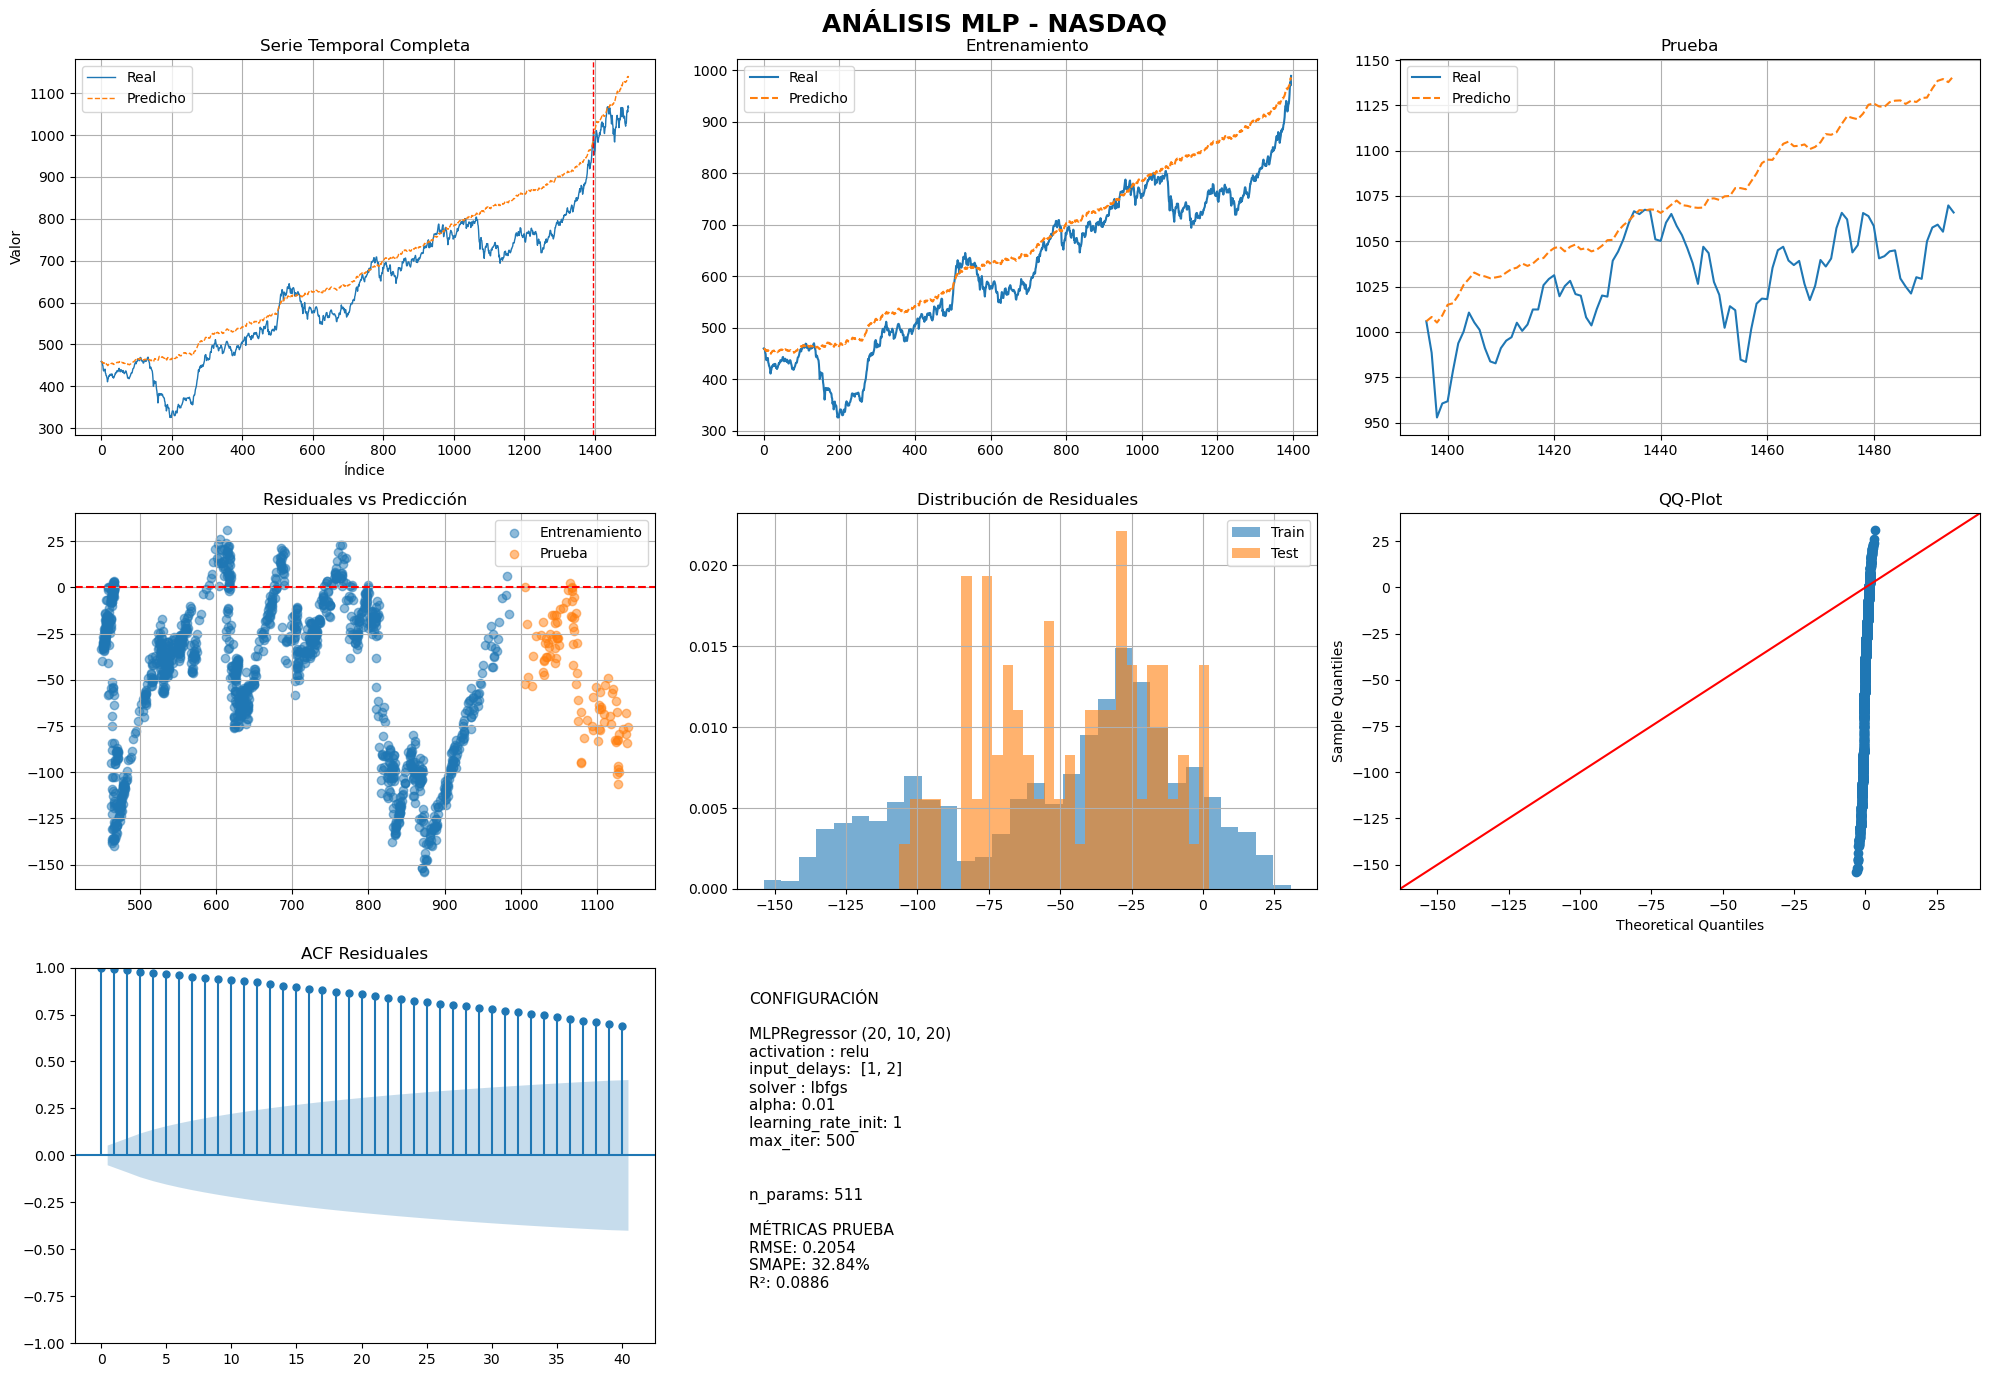

In [517]:
fig = fg_cs.graficar_dashboard_modelo_ARnet(
    train_series_true,
    train_series_pred,
    test_series_true,
    test_series_pred,
    idx_tr,
    idx_te,
    idx_full,
    series_true_full,
    series_pred_full,
    metrics_out,
    n_tr,
    n_params_real,
    config_text=modelo_text ,
    titulo="ANÁLISIS MLP - NASDAQ"
)

### Guardar modelo y resultados

In [519]:
joblib.dump(arnet, "arnet_model_fixed.pkl")
joblib.dump(scaler, "arnet_scaler_fixed.pkl")
print("\nModelo guardado: arnet_model_fixed.pkl")
print("Scaler guardado: arnet_scaler_fixed.pkl")

with open("arnet_model_metrics_fixed.txt", "w", encoding="utf-8") as f:
    f.write("=== MODELO ARNET (MLPRegressor) ===\n")
    for k, v in fixed_params.items():
        f.write(f"{k}: {v}\n")
    f.write(f"n_params_calculado: {n_params_real}\n")
    f.write(f"training_time_s: {train_time:.4f}\n\n")

    f.write("=== MÉTRICAS IN-SAMPLE (ENTRENAMIENTO) ===\n")
    for k, v in metrics_in.items():
        f.write(f"{k}: {v}\n")

    f.write("\n=== MÉTRICAS OUT-OF-SAMPLE (PRUEBA) ===\n")
    for k, v in metrics_out.items():
        f.write(f"{k}: {v}\n")

print("Métricas guardadas: arnet_model_metrics_fixed.txt")

print("\nListo.")



Modelo guardado: arnet_model_fixed.pkl
Scaler guardado: arnet_scaler_fixed.pkl
Métricas guardadas: arnet_model_metrics_fixed.txt

Listo.
